In [1]:
!pip install pandas openpyxl spacy

In [2]:
import zipfile
import pandas as pd
import os
import re
from openpyxl import load_workbook

zip_path = "/content/English.zip"
extract_folder = "/content/extracted"

# Bianca's annotation colors
REMOVE_COLORS = {
    "FFFFFF00",  # yellow
    "FF00FFFF"   # light blue
}


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

all_rows = []

for root, dirs, files in os.walk(extract_folder):

    for file in files:

        if file.endswith(".xlsx") and re.search(r'[_ ]bianca', file, re.IGNORECASE):

            file_path = os.path.join(root, file)
            adjective = re.split(r'[_ ]Bianca', file, maxsplit=1)[0]

            wb = load_workbook(file_path, data_only=True)
            ws = wb.active

            # header row
            headers = [cell.value for cell in ws[1]]

            for row in ws.iter_rows(min_row=2):

                remove_row = False

                # Check whether any cell in the row has a Bianca annotation color
                for cell in row:

                    fill = cell.fill

                    if fill and fill.fill_type:
                        color = fill.fgColor.rgb

                        if color in REMOVE_COLORS:
                            remove_row = True
                            break

                if remove_row:
                    continue

                row_data = [cell.value for cell in row]

                # Skip completely empty rows
                if all(v is None for v in row_data):
                    continue

                record = dict(zip(headers, row_data))
                record["adjective"] = adjective

                all_rows.append(record)
combined_df = []
combined_df = pd.DataFrame(all_rows)

combined_df.to_excel(
    "/content/combined_Bianca.xlsx",
    index=False
)

print(f"Rows kept: {len(combined_df)}")
print(combined_df.head())

Rows kept: 3056
              file Domain Gender  sent_index  token_id     token_form  \
0  Art13_en.conllu    Art      M        51.0       6.0  extraordinary   
1  Art13_en.conllu    Art      M        51.0       9.0  extraordinary   
2  Art13_en.conllu    Art      M        56.0      12.0  extraordinary   
3  Art13_en.conllu    Art      M        86.0       4.0  extraordinary   
4  Art13_en.conllu    Art      M        90.0       4.0  extraordinary   

     token_lemma                                           sentence  \
0  extraordinary  It 's energy that creates extraordinary interv...   
1  extraordinary  It 's energy that creates extraordinary interv...   
2  extraordinary  And so he filled the room , and we had an extr...   
3  extraordinary  There 's an extraordinary woman named Clare Bo...   
4  extraordinary  She did an extraordinary play called " The Wom...   

  EN_Evaluative? EN_Attitude_type  de_aligned_forms de_aligned_lemmas  \
0     Evaluative     Appreciation  außergewöh

# Positive vs. Negative

In [3]:
import pandas as pd
import spacy
from pathlib import Path

# Load English model
nlp = spacy.load("en_core_web_sm")

# download: https://github.com/happy522/LREC2026-EmotionalizTED-Corpus/blob/main/NEW%20analysis/combined_Bianca.xlsx

INPUT_FILE = "/content/combined_Bianca.xlsx"
SENTENCE_COL = "sentence"
ADJ_COL = "adjective"  # change if your column name differs

NEGATION_WORDS = {
    "not",
    "never",
    "no",
    "n't"
}


"""

NOTE:I've checked all sentences with these phrases and negators but it doesnt have any occurance of this.

NEGATION_PHRASES = {
    "no longer",
    "by no means",
    "in no way",
    "under no circumstances",
    "on no account"
}

BORDERLINE_NEGATORS = {
    "hardly",
    "barely",
    "scarcely",
    "rarely",
    "seldom"
}
"""

def is_negated_adjective(sentence, adjective):
    """
    Detect whether the target adjective is negated.
    Returns:
        (True/False, negation_type)
    """

    if pd.isna(sentence) or pd.isna(adjective):
        return False, None

    doc = nlp(str(sentence))
    adjective = str(adjective).lower()

    for token in doc:

        if token.lemma_.lower() != adjective:
            continue

        # Direct dependency negation
        for child in token.children:
            if child.dep_ == "neg":
                return True, child.text

        # Negation attached to adjective head
        if token.head:
            for child in token.head.children:
                if child.dep_ == "neg":
                    return True, child.text

        # Common negation words nearby
        window = doc[max(0, token.i - 4): min(len(doc), token.i + 5)]

        for nearby in window:
            if nearby.lower_ in NEGATION_WORDS:
                return True, nearby.text

        # "no longer"
        text = sentence.lower()
        if "no longer" in text:
            return True, "no longer"

    return False, None


def split_positive_negative(df):

    negative_rows = []
    positive_rows = []

    for _, row in df.iterrows():

        sentence = row[SENTENCE_COL]
        adjective = row[ADJ_COL]

        negated, neg_type = is_negated_adjective(
            sentence,
            adjective
        )

        row_copy = row.copy()

        if negated:
            row_copy["negation_type"] = neg_type
            negative_rows.append(row_copy)
        else:
            positive_rows.append(row_copy)

    negative_df = pd.DataFrame(negative_rows)
    positive_df = pd.DataFrame(positive_rows)

    return positive_df, negative_df

df = pd.read_excel(INPUT_FILE)

df.columns = (
    df.columns
    .str.replace("?", "", regex=False)
    .str.strip()
    .str.replace(" ", "_")
)

positive_df, negative_df = split_positive_negative(df)

positive_df.to_excel(
    "positive.xlsx",
    index=False
)

negative_df.to_excel(
    "negative.xlsx",
    index=False
)

print(f"Positive rows: {len(positive_df)}")
print(f"Negative rows: {len(negative_df)}")



Positive rows: 2835
Negative rows: 221


# Evaluative vs. Non-Evaluative

In [4]:
cols = ["EN_Evaluative", "DE_Evaluative"]

for c in cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace("nan", pd.NA)
    )

### Per adjective frequencies:

* EN_eval
* EN_non_eval
* EN_eval_not_speaker
* DE equivalents

In [5]:
table_a = (
    df.groupby("adjective")
      .agg(
          total_occurrences=("adjective", "size"),

          EN_eval=("EN_Evaluative",
                   lambda x: (x == "evaluative").sum()),

          EN_non_eval=("EN_Evaluative",
                       lambda x: (x == "non-evaluative").sum()),

          EN_eval_not_speaker=("EN_Evaluative",
                               lambda x: (x == "evaluative-not_speaker").sum()),

          DE_eval=("DE_Evaluative",
                   lambda x: (x == "evaluative").sum()),

          DE_non_eval=("DE_Evaluative",
                       lambda x: (x == "non-evaluative").sum()),

          DE_eval_not_speaker=("DE_Evaluative",
                               lambda x: (x == "evaluative-not_speaker").sum())
      )
      .reset_index()
)
table_a

,adjective,total_occurrences,EN_eval,EN_non_eval,EN_eval_not_speaker,DE_eval,DE_non_eval,DE_eval_not_speaker
0,amazing,123,120,0,3,118,2,3
1,bad,250,200,8,42,194,17,39
2,beautiful,73,61,2,9,60,3,9
3,creative,54,35,12,7,35,12,7
4,different,391,375,1,15,355,21,15
5,difficult,65,56,0,8,57,1,6
6,extraordinary,36,36,0,0,33,3,0
7,fantastic,25,25,0,0,25,0,0
8,fascinating,27,25,0,2,25,0,2
9,good,845,674,111,59,661,124,56


Overall EN evaluativity distribution.

In [6]:
table_b = (
    df["EN_Evaluative"]
    .value_counts(dropna=False)
    .rename_axis("EN_Evaluative_Status")
    .reset_index(name="Count")
)

table_b["Percentage"] = (
    table_b["Count"]
    / table_b["Count"].sum()
    * 100
).round(2)

### Overall DE evaluativity distribution.

In [7]:
table_b_de = (
    df["DE_Evaluative"]
    .value_counts(dropna=False)
    .rename_axis("DE_Evaluative_Status")
    .reset_index(name="Count")
)

table_b_de["Percentage"] = (
    table_b_de["Count"]
    / table_b_de["Count"].sum()
    * 100
).round(2)

table_b_de

,DE_Evaluative_Status,Count,Percentage
0,evaluative,2424,79.32
1,non-evaluative,328,10.73
2,evaluative-not_speaker,296,9.69
3,uncertain,5,0.16
4,<NA>,3,0.10


In [8]:
eval_df = df[
    df["EN_Evaluative"] != "non-evaluative"
]

### Overall English Attitude types.

In [11]:
table_c = (
    eval_df.loc[eval_df["EN_Attitude_type"] != "Uncertain", "EN_Attitude_type"]
    .value_counts()
    .rename_axis("Attitude")
    .reset_index(name="Count")
)

table_c["Percentage"] = (
    table_c["Count"] / table_c["Count"].sum() * 100
).round(2)

table_c

,Attitude,Count,Percentage
0,Appreciation,2238,79.56
1,Judgement,448,15.93
2,Affect,127,4.51


In [12]:
table_c = (
    eval_df.loc[eval_df["DE_Attitude_type"] != "Uncertain", "DE_Attitude_type"]
    .value_counts()
    .rename_axis("Attitude")
    .reset_index(name="Count")
)

table_c["Percentage"] = (
    table_c["Count"] / table_c["Count"].sum() * 100
).round(2)

table_c

,Attitude,Count,Percentage
0,Appreciation,2143,79.34
1,Judgement,434,16.07
2,Affect,124,4.59


### Attitude × evaluativity source (speaker vs not-speaker).

In [13]:
table_c1 = pd.crosstab(
    eval_df["EN_Attitude_type"],
    eval_df["EN_Evaluative"]
)

table_c1



EN_Evaluative,evaluative,evaluative-not_speaker
EN_Attitude_type,,
Affect,37,90
Appreciation,2076,162
Judgement,387,61
Uncertain,16,0


In [14]:
table_c1 = pd.crosstab(
    eval_df["DE_Attitude_type"],
    eval_df["DE_Evaluative"]
)

table_c1

DE_Evaluative,evaluative,evaluative-not_speaker,non-evaluative
DE_Attitude_type,,,
Affect,38,86,0
Appreciation,1993,149,1
Judgement,374,60,0
Uncertain,15,0,0


### Overall Attitude Distribution

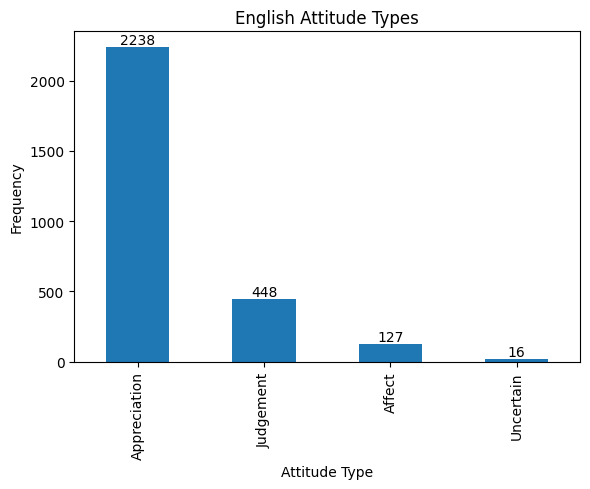

In [15]:
import matplotlib.pyplot as plt

counts = (
    eval_df["EN_Attitude_type"]
    .value_counts()
)

plt.figure(figsize=(6, 5))

counts.plot(kind="bar")

#adding count values on top of the bars
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.ylabel("Frequency")
plt.xlabel("Attitude Type")
plt.title("English Attitude Types")

plt.tight_layout()
plt.savefig("graph1_attitude_distribution.png",dpi = 1200)

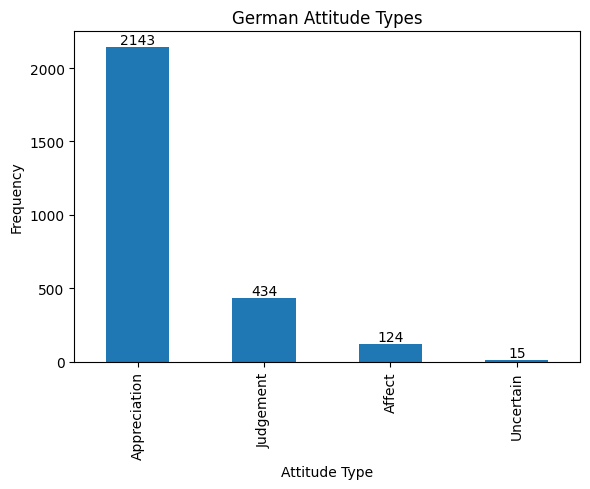

In [16]:
import matplotlib.pyplot as plt

counts = (
    eval_df["DE_Attitude_type"]
    .value_counts()
)

plt.figure(figsize=(6, 5))

counts.plot(kind="bar")

#adding count values on top of the bars
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.ylabel("Frequency")
plt.xlabel("Attitude Type")
plt.title("German Attitude Types")

plt.tight_layout()
plt.savefig("graph1_attitude_distribution_DE.png",dpi = 1200)

### Attitude Distribution per Adjective

In [19]:
attitude_by_adj = pd.crosstab(
    eval_df["adjective"],
    eval_df["EN_Attitude_type"]
)

In [20]:
# ============================================================
# EN Attitude Type Distribution — Per Adjective
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Filter: EN evaluative rows only (same logic as eval_df) ---
en_att_df = df[df["EN_Evaluative"] != "non-evaluative"].copy()
en_att_df = en_att_df[en_att_df["EN_Attitude_type"].notna()]

# --- TABLE: Raw counts ---
en_att_per_adj = (
    en_att_df
    .groupby(["adjective", "EN_Attitude_type"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)

# Add row totals
en_att_per_adj["Total_Evaluative"] = en_att_per_adj.drop(columns="adjective").sum(axis=1)

print("=== EN Attitude Type per Adjective (Raw Counts) ===")
print(en_att_per_adj.to_string(index=False))

# --- TABLE: Row percentages ---
att_cols = [c for c in en_att_per_adj.columns if c not in ("adjective", "Total_Evaluative")]

en_att_pct = en_att_per_adj[["adjective", "Total_Evaluative"]].copy()
for col in att_cols:
    en_att_pct[col + "_%"] = (
        en_att_per_adj[col] / en_att_per_adj["Total_Evaluative"] * 100
    ).round(1)

print("\n=== EN Attitude Type per Adjective (Row %) ===")
print(en_att_pct.to_string(index=False))


=== EN Attitude Type per Adjective (Raw Counts) ===
    adjective  Affect  Appreciation  Judgement  Uncertain  Total_Evaluative
      amazing       0           103         20          0               123
          bad       8           199         33          2               242
    beautiful       0            60         10          0                70
     creative       0            14         28          0                42
    different       3           351         35          1               390
    difficult       0            63          0          1                64
extraordinary       0            31          5          0                36
    fantastic       0            21          4          0                25
  fascinating       0            25          2          0                27
         good      10           545        171          7               733
        happy     102            13          0          0               115
    important       0           240 

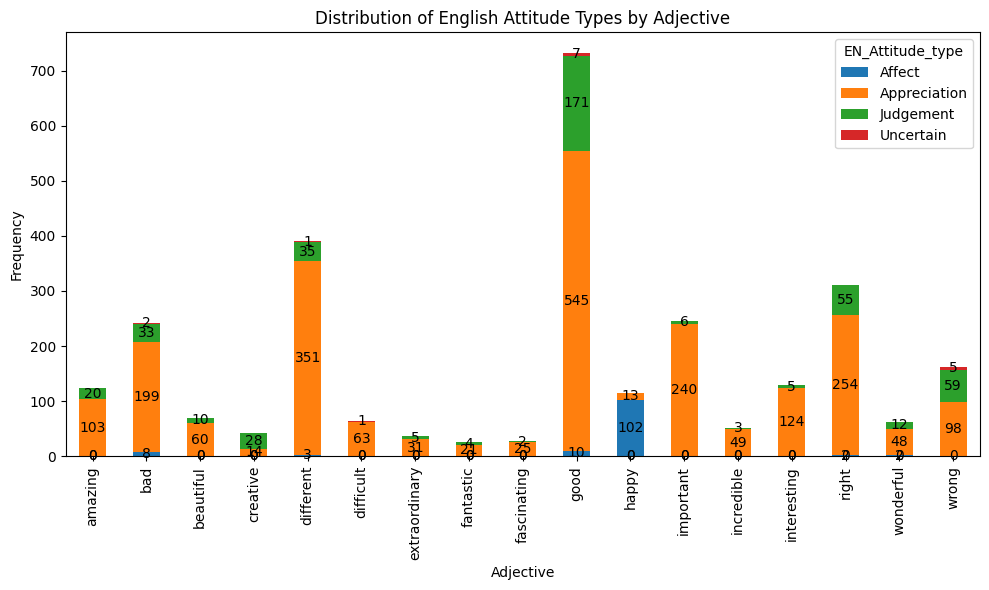

In [21]:
ax = attitude_by_adj.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Frequency")
plt.xlabel("Adjective")
plt.title("Distribution of English Attitude Types by Adjective")

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",   # puts number inside bar
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.savefig("graph2_attitude_by_adjective.png", dpi=1200)

=== Overall DE Attitude Type Distribution ===
DE_Attitude_type  Count  Percentage
    Appreciation   2143       78.90
       Judgement    434       15.98
          Affect    124        4.57
       Uncertain     15        0.55

=== DE Attitude Type per Adjective (Raw Counts) ===
    adjective  Affect  Appreciation  Judgement  Uncertain  Total_with_DE_tag
      amazing       0           101         20          0                121
          bad       9           191         31          2                233
    beautiful       0            58         11          0                 69
     creative       0            15         27          0                 42
    different       3           326         38          1                368
    difficult       0            63          0          0                 63
extraordinary       0            28          5          0                 33
    fantastic       0            21          4          0                 25
  fascinating       0       

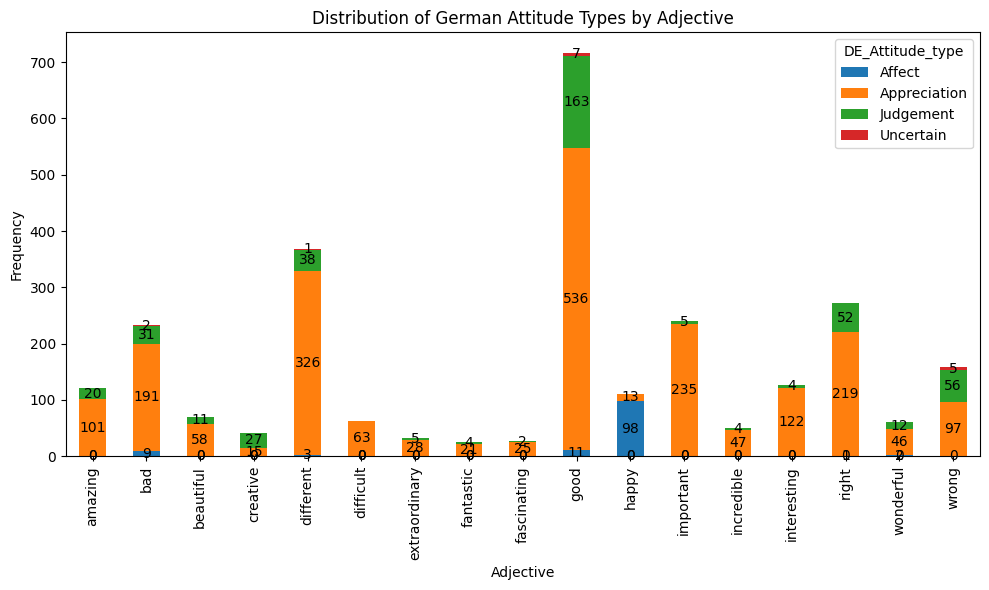

In [ ]:
attitude_by_adj = pd.crosstab(
    eval_df["adjective"],
    eval_df["DE_Attitude_type"]
)

# ============================================================
# DE Attitude Type Distribution — Overall + Per Adjective
# ============================================================

# Filter: EN must be evaluative (per Mirela's instruction —
# we only care about DE translation of EN evaluative uses)
de_att_df = df[df["EN_Evaluative"] != "non-evaluative"].copy()
de_att_df = de_att_df[de_att_df["DE_Attitude_type"].notna()]

# --- TABLE: Overall DE Attitude type distribution ---
table_de_att = (
    de_att_df["DE_Attitude_type"]
    .value_counts()
    .rename_axis("DE_Attitude_type")
    .reset_index(name="Count")
)
table_de_att["Percentage"] = (
    table_de_att["Count"] / table_de_att["Count"].sum() * 100
).round(2)

print("=== Overall DE Attitude Type Distribution ===")
print(table_de_att.to_string(index=False))

# --- TABLE: DE Attitude type per adjective (raw counts) ---
de_att_per_adj = (
    de_att_df
    .groupby(["adjective", "DE_Attitude_type"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
de_att_per_adj["Total_with_DE_tag"] = de_att_per_adj.drop(columns="adjective").sum(axis=1)

print("\n=== DE Attitude Type per Adjective (Raw Counts) ===")
print(de_att_per_adj.to_string(index=False))

# --- TABLE: Row percentages ---
de_att_cols = [c for c in de_att_per_adj.columns if c not in ("adjective", "Total_with_DE_tag")]
de_att_pct = de_att_per_adj[["adjective", "Total_with_DE_tag"]].copy()
for col in de_att_cols:
    de_att_pct[col + "_%"] = (
        de_att_per_adj[col] / de_att_per_adj["Total_with_DE_tag"] * 100
    ).round(1)

print("\n=== DE Attitude Type per Adjective (Row %) ===")
print(de_att_pct.to_string(index=False))


ax = attitude_by_adj.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Frequency")
plt.xlabel("Adjective")
plt.title("Distribution of German Attitude Types by Adjective")

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",   # puts number inside bar
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.savefig("graph2_attitude_by_adjective_DE.png", dpi=1200)

# Attitude in EN and DE

In [ ]:
table_attitude = pd.crosstab(
    eval_df["EN_Attitude_type"],
    eval_df["DE_Attitude_type"]
)

table_attitude

DE_Attitude_type,Affect,Appreciation,Judgement,Uncertain
EN_Attitude_type,,,,
Affect,122,0,0,0
Appreciation,2,2131,13,0
Judgement,0,11,421,0
Uncertain,0,1,0,15


In [ ]:
df["attitude_match"] = (
    df["EN_Attitude_type"] == df["DE_Attitude_type"]
)

total = len(df)

mismatch_count = (~df["attitude_match"]).sum()
match_count = df["attitude_match"].sum()

mismatch_rate = mismatch_count / total
match_rate = match_count / total

print("Mismatch rate:", round(mismatch_rate, 4))
print("Match rate:", round(match_rate, 4))

Mismatch rate: 0.1191
Match rate: 0.8809


## Chi-square test (association test)
Is EN Attitude independent of DE Attitude?
* p < 0.05 → EN attitude significantly associated with DE attitude (translation is not random)
* p ≥ 0.05 → no strong evidence of systematic shift

In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table_attitude)

print("Chi-square:", chi2)
print("df:", dof)
print("p-value:", p)

#translation is not random

Chi-square: 7752.884250799323
df: 9
p-value: 0.0



## Effect size
* ~0.1 = small shift
* ~0.3 = moderate shift
* ~0.5+ = strong systematic translation restructuring

In [ ]:
import numpy as np

n = table_attitude.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(table_attitude.shape) - 1))
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.975452530884889


Working dataset: 195 rows, 16 adjectives

Behavioural Profile matrix: 16 adjectives × 23 features
               EN_Affect  EN_Appreciation  EN_Judgement  DE_Affect  \
adjective                                                            
amazing            0.000            0.750         0.250      0.000   
bad                0.056            0.833         0.111      0.056   
beautiful          0.000            1.000         0.000      0.000   
different          0.000            0.824         0.176      0.000   
difficult          0.000            1.000         0.000      0.000   
extraordinary      0.000            1.000         0.000      0.000   
fantastic          0.000            0.333         0.667      0.000   
fascinating        0.000            1.000         0.000      0.000   
good               0.000            0.781         0.219      0.016   
happy              0.000            1.000         0.000      0.000   
important          0.000            1.000         0.000      0

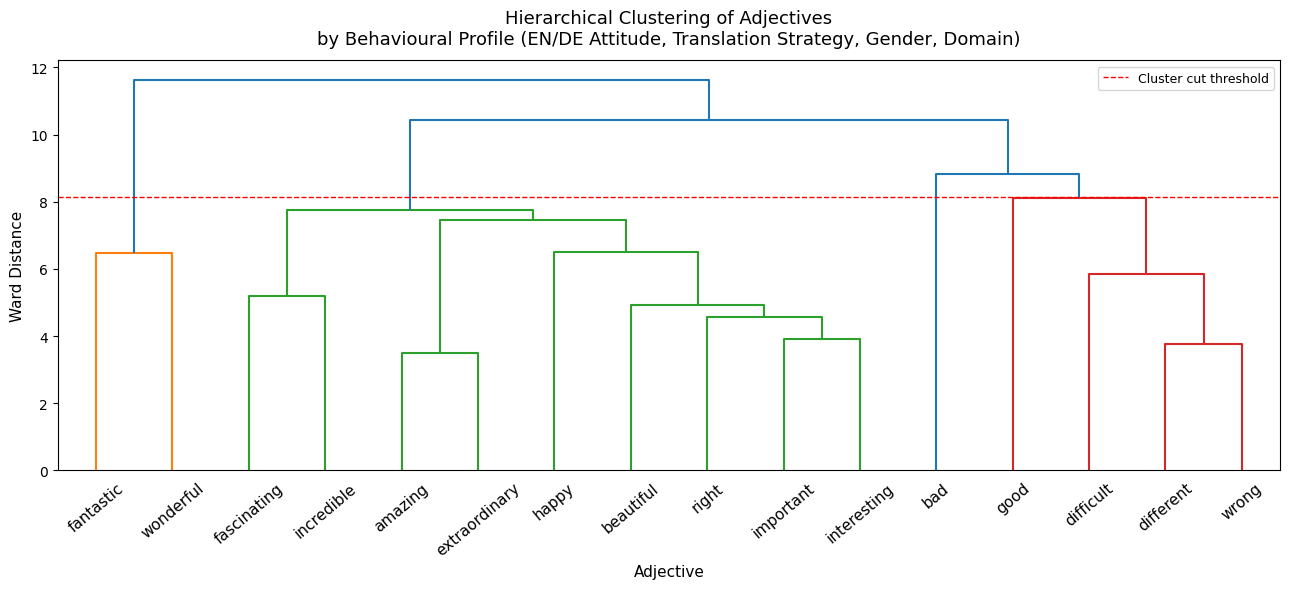


Silhouette scores: {2: np.float64(0.211708240421374), 3: np.float64(0.13707238074959693), 4: np.float64(0.13911128032659645), 5: np.float64(0.12644254013747772), 6: np.float64(0.13003306953641008), 7: np.float64(0.13953845868867518)}
Optimal k (highest silhouette): 2


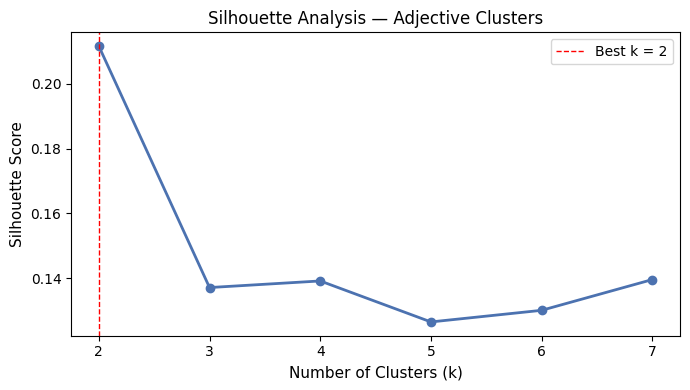


=== Adjective Cluster Assignments (k=2) ===
    adjective  Cluster
    fantastic        1
    wonderful        1
    beautiful        2
      amazing        2
    different        2
    difficult        2
extraordinary        2
          bad        2
  fascinating        2
         good        2
    important        2
        happy        2
   incredible        2
  interesting        2
        right        2
        wrong        2

=== Mean Feature Values per Cluster ===
Cluster               1      2
EN_Affect         0.000  0.004
EN_Appreciation   0.417  0.924
EN_Judgement      0.583  0.072
DE_Affect         0.000  0.005
DE_Appreciation   0.417  0.890
DE_Judgement      0.583  0.105
TS_Alteration     1.000  0.998
TS_Equivalence    0.000  0.002
TE_Explicitation  0.000  0.340
TE_Implicitation  1.000  0.660
GEN_F             0.750  0.532
GEN_M             0.250  0.468
DOM_Art           0.500  0.108
DOM_Bus           0.333  0.124
DOM_Edu           0.000  0.083
DOM_Ent           0.000  0.

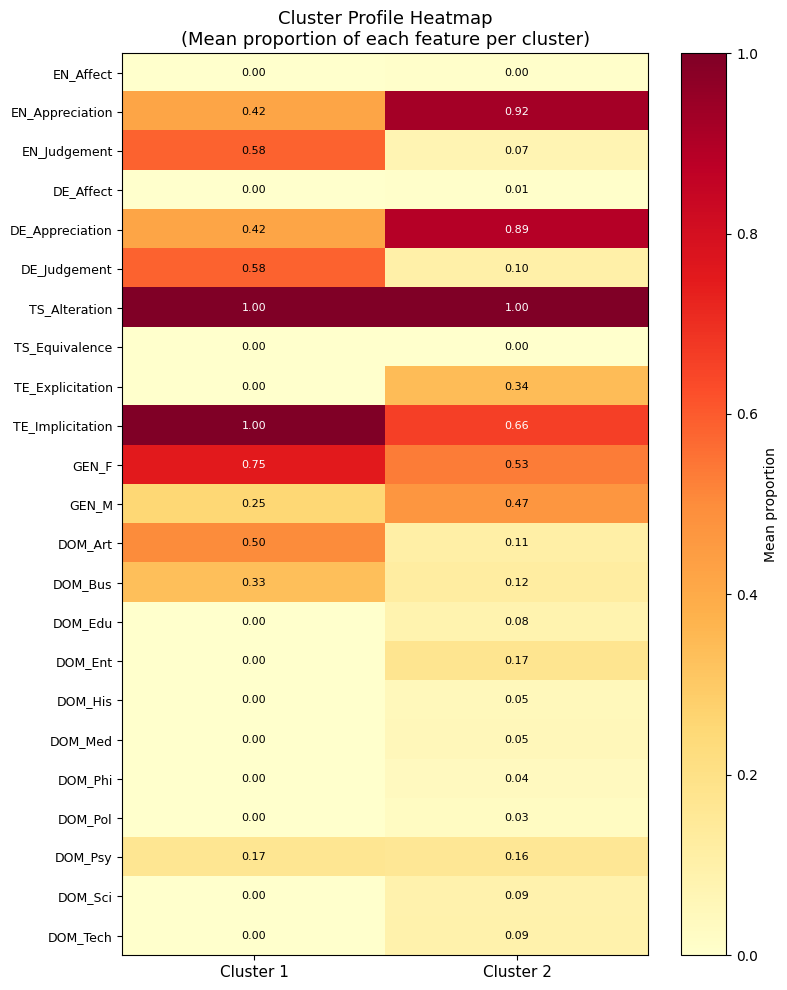


Pattern cluster silhouette scores: {2: np.float64(0.689443243391514), 3: np.float64(0.7188699931557427), 4: np.float64(0.8689909001427042), 5: np.float64(0.9174122014851075), 6: np.float64(0.9178799446589048), 7: np.float64(0.9547291092354371), 8: np.float64(0.9778937438640376)}
Optimal k for translation patterns: 8


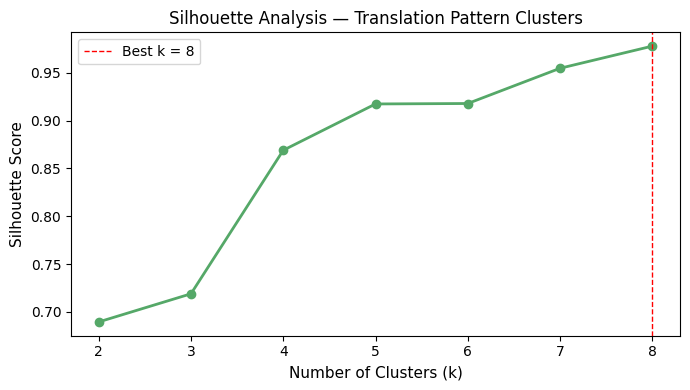


=== Translation Pattern Cluster Composition (k=8) ===

--- Cluster 0  (n=72) ---
  EN_Attitude_type: {'Appreciation': 100.0}
  DE_Attitude_type: {'Appreciation': 100.0}
  Translation_strategy: {'Alteration': 100.0}
  Translationese_effect: {'Explicitation': 100.0}

--- Cluster 1  (n=18) ---
  EN_Attitude_type: {'Judgement': 100.0}
  DE_Attitude_type: {'Judgement': 94.4, 'Appreciation': 5.6}
  Translation_strategy: {'Alteration': 100.0}
  Translationese_effect: {'Implicitation': 100.0}

--- Cluster 2  (n=86) ---
  EN_Attitude_type: {'Appreciation': 100.0}
  DE_Attitude_type: {'Appreciation': 100.0}
  Translation_strategy: {'Alteration': 100.0}
  Translationese_effect: {'Implicitation': 100.0}

--- Cluster 3  (n=2) ---
  EN_Attitude_type: {'Appreciation': 100.0}
  DE_Attitude_type: {'Appreciation': 100.0}
  Translation_strategy: {'Equivalence': 100.0}
  Translationese_effect: {'Explicitation': 100.0}

--- Cluster 4  (n=1) ---
  EN_Attitude_type: {'Affect': 100.0}
  DE_Attitude_type: {'A

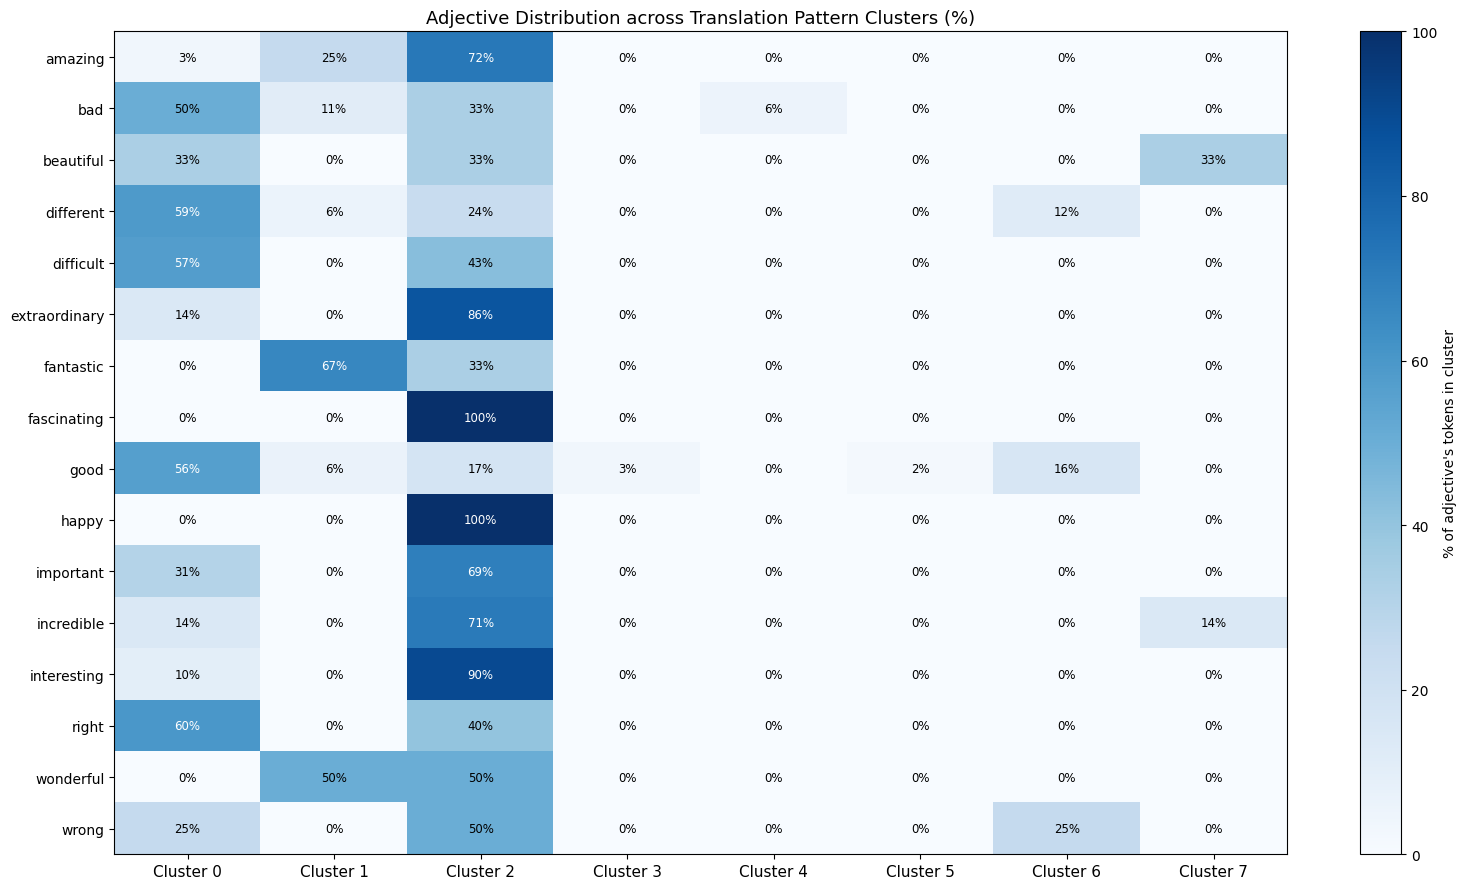

In [ ]:
# ============================================================
# Cluster Analysis
# Part A: Cluster adjectives by their behavioural profile
#         (Behavioural Profiles approach — Gries & Divjak)
# Part B: Cluster translation patterns (row-level)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings("ignore")

# ── Base filter: EN evaluative rows only ──────────────────────────────────────
cl_df = df[df["EN_Evaluative"] != "non-evaluative"].copy()
cl_df = cl_df.dropna(subset=[
    "EN_Attitude_type", "DE_Attitude_type",
    "Translation_strategy", "Translationese_effect",
    "Gender", "Domain"
])

print(f"Working dataset: {len(cl_df)} rows, {cl_df['adjective'].nunique()} adjectives")


# ════════════════════════════════════════════════════════════
# PART A — ADJECTIVE BEHAVIOURAL PROFILES
# Build a feature vector per adjective (normalised frequencies)
# following the Behavioural Profiles approach (Gries & Divjak)
# ════════════════════════════════════════════════════════════

def prop_table(df, groupcol, valcol):
    """Return a proportion pivot: rows=adjective, cols=categories."""
    ct = pd.crosstab(df[groupcol], df[valcol])
    return ct.div(ct.sum(axis=1), axis=0)

# Build profile features — proportions of each category per adjective
en_att   = prop_table(cl_df, "adjective", "EN_Attitude_type").add_prefix("EN_")
de_att   = prop_table(cl_df, "adjective", "DE_Attitude_type").add_prefix("DE_")
ts       = prop_table(cl_df, "adjective", "Translation_strategy").add_prefix("TS_")
te       = prop_table(cl_df, "adjective", "Translationese_effect").add_prefix("TE_")
gender   = prop_table(cl_df, "adjective", "Gender").add_prefix("GEN_")
domain   = prop_table(cl_df, "adjective", "Domain").add_prefix("DOM_")

# Combine into one behavioural profile matrix
bp = pd.concat([en_att, de_att, ts, te, gender, domain], axis=1).fillna(0)

print(f"\nBehavioural Profile matrix: {bp.shape[0]} adjectives × {bp.shape[1]} features")
print(bp.round(3))


# ── A1. Hierarchical Clustering (Ward linkage) ────────────────────────────────

# Standardise features before clustering
scaler   = StandardScaler()
bp_scaled = scaler.fit_transform(bp)

# Euclidean distance + Ward linkage (standard for behavioural profiles)
dist_matrix = pdist(bp_scaled, metric="euclidean")
Z           = linkage(dist_matrix, method="ward")

fig, ax = plt.subplots(figsize=(13, 6))
dendrogram(
    Z,
    labels=bp.index.tolist(),
    ax=ax,
    leaf_rotation=40,
    leaf_font_size=11,
    color_threshold=0.7 * max(Z[:, 2]),   # auto-colour threshold at 70% of max height
)
ax.set_title(
    "Hierarchical Clustering of Adjectives\n"
    "by Behavioural Profile (EN/DE Attitude, Translation Strategy, Gender, Domain)",
    fontsize=13, pad=12
)
ax.set_xlabel("Adjective", fontsize=11)
ax.set_ylabel("Ward Distance", fontsize=11)
ax.axhline(
    y=0.7 * max(Z[:, 2]),
    color="red", linestyle="--", linewidth=1,
    label="Cluster cut threshold"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("graph_cluster_adjective_dendrogram.png", dpi=300)
plt.show()


# ── A2. Silhouette analysis to choose optimal k ───────────────────────────────

sil_scores = {}
k_range    = range(2, min(len(bp), 8))   # test k = 2..7

for k in k_range:
    labels = fcluster(Z, k, criterion="maxclust")
    if len(set(labels)) > 1:
        sil_scores[k] = silhouette_score(bp_scaled, labels)

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nSilhouette scores: {sil_scores}")
print(f"Optimal k (highest silhouette): {best_k}")

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(list(sil_scores.keys()), list(sil_scores.values()),
         marker="o", color="#4C72B0", linewidth=2)
ax2.axvline(best_k, color="red", linestyle="--", linewidth=1,
            label=f"Best k = {best_k}")
ax2.set_xlabel("Number of Clusters (k)", fontsize=11)
ax2.set_ylabel("Silhouette Score", fontsize=11)
ax2.set_title("Silhouette Analysis — Adjective Clusters", fontsize=12)
ax2.set_xticks(list(k_range))
ax2.legend(fontsize=10)
plt.tight_layout()
plt.savefig("graph_cluster_adjective_silhouette.png", dpi=300)
plt.show()


# ── A3. Cluster membership table ─────────────────────────────────────────────

cluster_labels = fcluster(Z, best_k, criterion="maxclust")
bp["Cluster"]  = cluster_labels

cluster_table = bp[["Cluster"]].reset_index()
cluster_table = cluster_table.sort_values("Cluster")

print(f"\n=== Adjective Cluster Assignments (k={best_k}) ===")
print(cluster_table.to_string(index=False))

# ── A4. Cluster profile summary — what characterises each cluster ─────────────

bp_with_cluster = bp.copy()
profile_summary = bp_with_cluster.groupby("Cluster").mean().round(3)

print("\n=== Mean Feature Values per Cluster ===")
print(profile_summary.T.to_string())   # transposed: features as rows

# Heatmap of cluster profiles
fig3, ax3 = plt.subplots(figsize=(max(8, best_k * 2), 10))
im = ax3.imshow(profile_summary.T.values, cmap="YlOrRd", aspect="auto")
ax3.set_xticks(range(best_k))
ax3.set_xticklabels([f"Cluster {i}" for i in range(1, best_k + 1)], fontsize=11)
ax3.set_yticks(range(len(profile_summary.columns)))
ax3.set_yticklabels(profile_summary.columns, fontsize=9)
ax3.set_title("Cluster Profile Heatmap\n(Mean proportion of each feature per cluster)",
              fontsize=13)
plt.colorbar(im, ax=ax3, label="Mean proportion")

for i in range(profile_summary.shape[0]):
    for j in range(profile_summary.shape[1]):
        val = profile_summary.T.values[j, i]
        ax3.text(i, j, f"{val:.2f}", ha="center", va="center",
                 fontsize=8, color="black" if val < 0.6 else "white")

plt.tight_layout()
plt.savefig("graph_cluster_adjective_heatmap.png", dpi=300)
plt.show()


# ════════════════════════════════════════════════════════════
# PART B — TRANSLATION PATTERN CLUSTERING (row-level)
# Groups individual EN→DE translation events by
# EN Attitude × DE Attitude × Strategy × Effect
# ════════════════════════════════════════════════════════════

# One-hot encode the 4 core translation variables
pattern_df = pd.get_dummies(cl_df[[
    "EN_Attitude_type",
    "DE_Attitude_type",
    "Translation_strategy",
    "Translationese_effect"
]].astype(str))

pattern_scaled = StandardScaler().fit_transform(pattern_df)

# ── B1. Silhouette to choose k ────────────────────────────────────────────────

sil_pat = {}
for k in range(2, 9):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pattern_scaled)
    sil_pat[k] = silhouette_score(pattern_scaled, labels)

best_k_pat = max(sil_pat, key=sil_pat.get)
print(f"\nPattern cluster silhouette scores: {sil_pat}")
print(f"Optimal k for translation patterns: {best_k_pat}")

fig4, ax4 = plt.subplots(figsize=(7, 4))
ax4.plot(list(sil_pat.keys()), list(sil_pat.values()),
         marker="o", color="#55A868", linewidth=2)
ax4.axvline(best_k_pat, color="red", linestyle="--", linewidth=1,
            label=f"Best k = {best_k_pat}")
ax4.set_xlabel("Number of Clusters (k)", fontsize=11)
ax4.set_ylabel("Silhouette Score", fontsize=11)
ax4.set_title("Silhouette Analysis — Translation Pattern Clusters", fontsize=12)
ax4.set_xticks(range(2, 9))
ax4.legend(fontsize=10)
plt.tight_layout()
plt.savefig("graph_cluster_pattern_silhouette.png", dpi=300)
plt.show()

# ── B2. Fit final KMeans ──────────────────────────────────────────────────────

km_final       = KMeans(n_clusters=best_k_pat, random_state=42, n_init=10)
cl_df          = cl_df.copy()
cl_df["Pattern_Cluster"] = km_final.fit_predict(pattern_scaled)

# ── B3. Cluster composition table ────────────────────────────────────────────

print(f"\n=== Translation Pattern Cluster Composition (k={best_k_pat}) ===")
for k in sorted(cl_df["Pattern_Cluster"].unique()):
    sub = cl_df[cl_df["Pattern_Cluster"] == k]
    print(f"\n--- Cluster {k}  (n={len(sub)}) ---")
    for col in ["EN_Attitude_type", "DE_Attitude_type",
                "Translation_strategy", "Translationese_effect"]:
        vc = sub[col].value_counts(normalize=True).mul(100).round(1)
        print(f"  {col}: {vc.to_dict()}")

# ── B4. Cluster × Adjective heatmap — which adjectives dominate each cluster ──

cl_adj = pd.crosstab(cl_df["adjective"], cl_df["Pattern_Cluster"])
cl_adj_pct = cl_adj.div(cl_adj.sum(axis=1), axis=0) * 100

fig5, ax5 = plt.subplots(figsize=(max(8, best_k_pat * 2), 9))
im2 = ax5.imshow(cl_adj_pct.values, cmap="Blues", aspect="auto")
ax5.set_xticks(range(best_k_pat))
ax5.set_xticklabels([f"Cluster {i}" for i in range(best_k_pat)], fontsize=11)
ax5.set_yticks(range(len(cl_adj_pct.index)))
ax5.set_yticklabels(cl_adj_pct.index, fontsize=10)
ax5.set_title(
    "Adjective Distribution across Translation Pattern Clusters (%)",
    fontsize=13
)
plt.colorbar(im2, ax=ax5, label="% of adjective's tokens in cluster")

for i in range(cl_adj_pct.shape[0]):
    for j in range(cl_adj_pct.shape[1]):
        val = cl_adj_pct.values[i, j]
        ax5.text(j, i, f"{val:.0f}%", ha="center", va="center",
                 fontsize=8.5, color="white" if val > 55 else "black")

plt.tight_layout()
plt.savefig("graph_cluster_pattern_adj_heatmap.png", dpi=300)
plt.show()

Total EN evaluative rows for the 7 adjectives: 2200
Adjective  Count
     good    734
different    390
    right    311
important    246
      bad    242
    wrong    162
    happy    115

=== Table 1: EN Evaluative / Non-Evaluative Counts (7 adjectives) ===
adjective  Total  EN_Evaluative  EN_NonEval  EN_Eval_NotSpk  Eval_%
     good    845            674         111              59    79.8
different    391            375           1              15    95.9
    right    385            284          74              27    73.8
      bad    250            200           8              42    80.0
important    247            221           1              25    89.5
    wrong    170            132           8              30    77.6
    happy    121             39           6              76    32.2

=== Table 2a: EN Attitude Type per Adjective — Raw Counts ===
           Affect  Appreciation  Judgement  Uncertain  Total
adjective                                                   
bad         

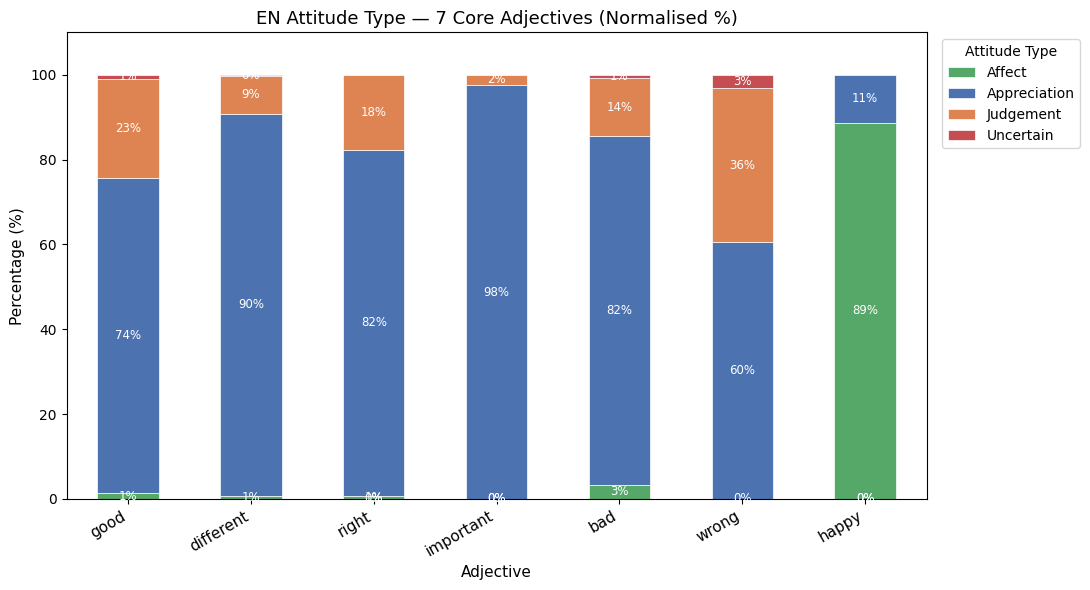

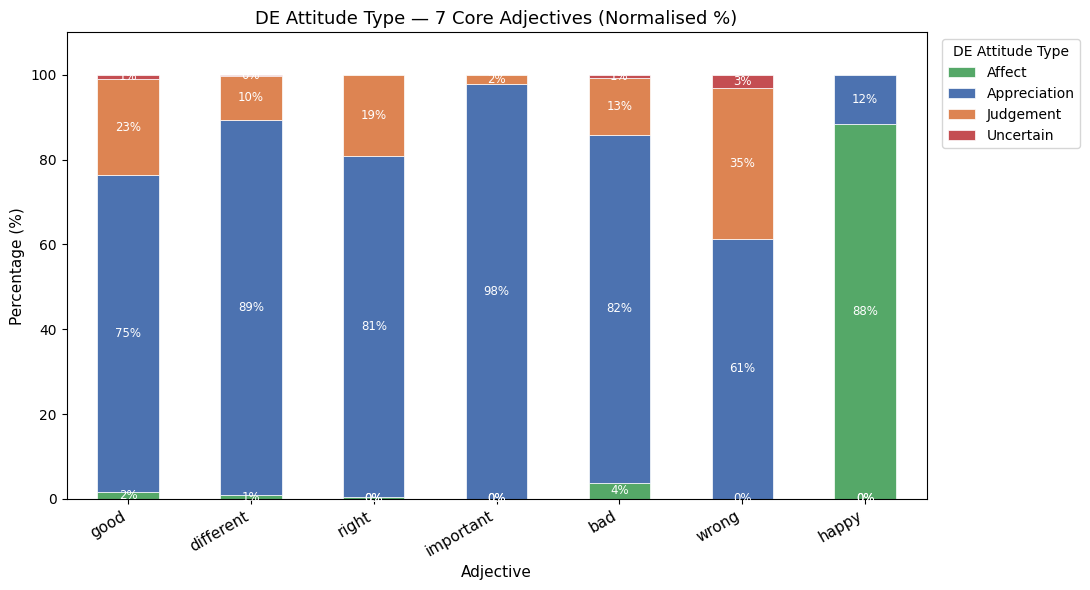

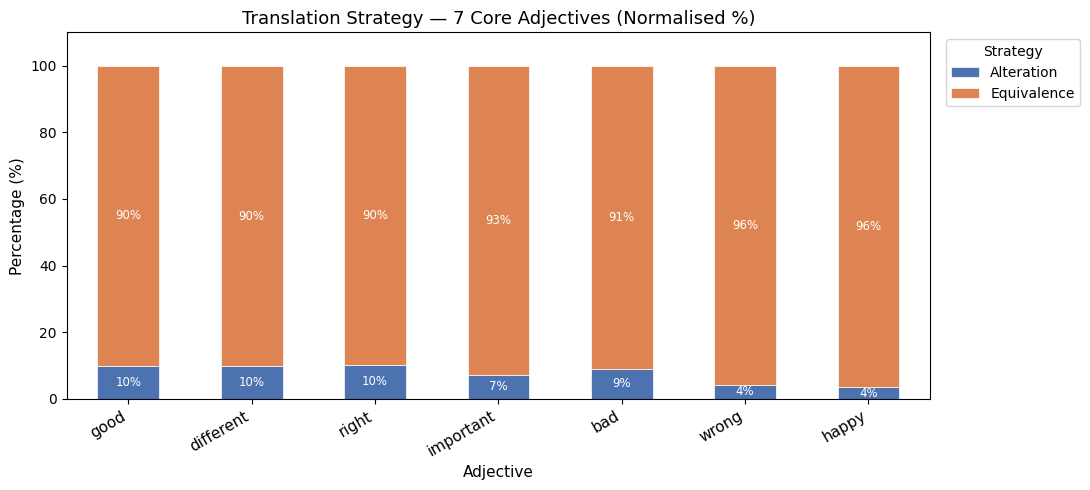

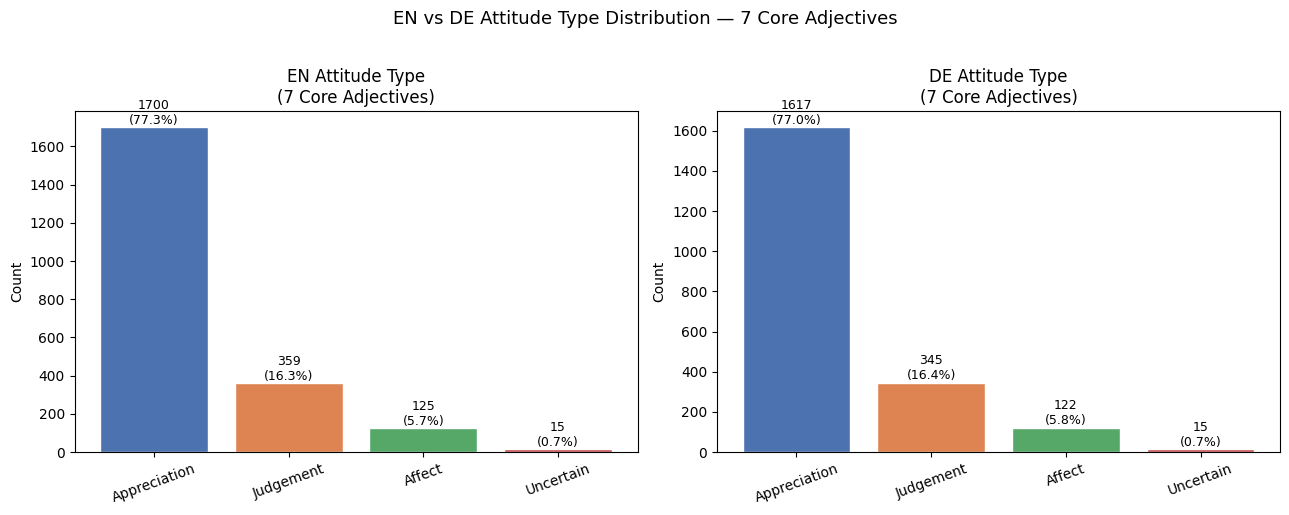


=== Comparison-Ready Summary (to be merged with incoming DE data) ===
adjective  n_EN_evaluative  EN_Appreciation_%  EN_Judgement_%  EN_Affect_%  EN_Uncertain_%  DE_Appreciation_%  DE_Judgement_%  DE_Affect_%  DE_Uncertain_%  TS_Equivalence_%  TS_Alteration_%  TE_Explicitation_%  TE_Implicitation_%
     good              734               74.3            23.3          1.4             1.0               74.8            22.7          1.5             1.0              90.0             10.0                65.8                34.2
important              246               97.6             2.4          0.0             0.0               97.9             2.1          0.0             0.0              92.7              7.3                22.2                77.8
    happy              115               11.3             0.0         88.7             0.0               11.7             0.0         88.3             0.0              96.5              3.5                 0.0               100.0
    right

In [23]:
# ============================================================
# Focus Analysis — 7 Core Adjectives
# good, important, happy, right, wrong, bad, different
#
# Purpose: produce all descriptive + statistical outputs
# scoped to these 7 adjectives, saved separately so results
# can later be compared with the additional DE-only data
# Mirela will share.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

# ── 0. Define the 7 core adjectives ──────────────────────────────────────────

CORE_7 = ["good", "important", "happy", "right", "wrong", "bad", "different"]

# Filter to EN evaluative rows, scoped to the 7 adjectives only
core_df = df[
    (df["EN_Evaluative"] != "non-evaluative") &
    (df["adjective"].str.lower().isin(CORE_7))
].copy()

# Ensure adjective column is lowercase for consistent labelling
core_df["adjective"] = core_df["adjective"].str.lower()

print(f"Total EN evaluative rows for the 7 adjectives: {len(core_df)}")
print(core_df["adjective"].value_counts().rename_axis("Adjective").reset_index(name="Count").to_string(index=False))


# ── 1. Evaluative vs Non-Evaluative counts (EN) ───────────────────────────────

eval_counts = (
    df[df["adjective"].str.lower().isin(CORE_7)]
    .groupby("adjective")
    .agg(
        Total          = ("adjective", "size"),
        EN_Evaluative  = ("EN_Evaluative", lambda x: (x == "evaluative").sum()),
        EN_NonEval     = ("EN_Evaluative", lambda x: (x == "non-evaluative").sum()),
        EN_Eval_NotSpk = ("EN_Evaluative", lambda x: (x == "evaluative-not_speaker").sum()),
    )
    .reset_index()
    .sort_values("Total", ascending=False)
)

eval_counts["Eval_%"] = (
    eval_counts["EN_Evaluative"] / eval_counts["Total"] * 100
).round(1)

print("\n=== Table 1: EN Evaluative / Non-Evaluative Counts (7 adjectives) ===")
print(eval_counts.to_string(index=False))


# ── 2. EN Attitude Type — per adjective ──────────────────────────────────────

en_att_7 = (
    core_df.groupby(["adjective", "EN_Attitude_type"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
)
en_att_7["Total"] = en_att_7.sum(axis=1)

# Row percentages
att_cols = [c for c in en_att_7.columns if c != "Total"]
en_att_7_pct = en_att_7[att_cols].div(en_att_7["Total"], axis=0).mul(100).round(1)

print("\n=== Table 2a: EN Attitude Type per Adjective — Raw Counts ===")
print(en_att_7.to_string())

print("\n=== Table 2b: EN Attitude Type per Adjective — Row % ===")
print(en_att_7_pct.to_string())


# ── 3. DE Attitude Type — per adjective ──────────────────────────────────────

de_att_7 = (
    core_df.dropna(subset=["DE_Attitude_type"])
    .groupby(["adjective", "DE_Attitude_type"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
)
de_att_7["Total"] = de_att_7.sum(axis=1)

de_att_cols = [c for c in de_att_7.columns if c != "Total"]
de_att_7_pct = de_att_7[de_att_cols].div(de_att_7["Total"], axis=0).mul(100).round(1)

print("\n=== Table 3a: DE Attitude Type per Adjective — Raw Counts ===")
print(de_att_7.to_string())

print("\n=== Table 3b: DE Attitude Type per Adjective — Row % ===")
print(de_att_7_pct.to_string())


# ── 4. EN→DE Attitude Type Mismatch ──────────────────────────────────────────

mismatch_df = core_df.dropna(subset=["EN_Attitude_type", "DE_Attitude_type"])
mismatch_df = mismatch_df[mismatch_df["EN_Attitude_type"] != "Uncertain"]

ct_mismatch = pd.crosstab(
    mismatch_df["EN_Attitude_type"],
    mismatch_df["DE_Attitude_type"],
    margins=True
)

print("\n=== Table 4: EN→DE Attitude Type Cross-tabulation (7 adjectives) ===")
print(ct_mismatch.to_string())

# Chi-square on without margins
ct_raw = pd.crosstab(mismatch_df["EN_Attitude_type"], mismatch_df["DE_Attitude_type"])
chi2, p, dof, expected = chi2_contingency(ct_raw)
n    = ct_raw.values.sum()
cv   = np.sqrt(chi2 / (n * (min(ct_raw.shape) - 1)))

print(f"\nChi-square = {chi2:.3f}, df = {dof}, p = {p:.4f}")
print(f"Cramér's V = {cv:.4f}")


# ── 5. Translation Strategy & Translationese Effects ─────────────────────────

ts_7 = core_df.dropna(subset=["Translation_strategy"])

table_ts7 = (
    ts_7.groupby(["adjective", "Translation_strategy"])
    .size().unstack(fill_value=0)
    .rename_axis(columns=None)
)
table_ts7["Total"] = table_ts7.sum(axis=1)
ts_cols7 = [c for c in table_ts7.columns if c != "Total"]
table_ts7_pct = table_ts7[ts_cols7].div(table_ts7["Total"], axis=0).mul(100).round(1)

print("\n=== Table 5a: Translation Strategy per Adjective — Raw Counts ===")
print(table_ts7.to_string())
print("\n=== Table 5b: Translation Strategy per Adjective — Row % ===")
print(table_ts7_pct.to_string())

# Translationese effects (Alteration only)
alt_7 = core_df[
    (core_df["Translation_strategy"] == "Alteration") &
    (core_df["Translationese_effect"].notna())
]
table_te7 = (
    alt_7.groupby(["adjective", "Translationese_effect"])
    .size().unstack(fill_value=0)
    .rename_axis(columns=None)
)
table_te7["Total_Alteration"] = table_te7.sum(axis=1)
te_cols7 = [c for c in table_te7.columns if c != "Total_Alteration"]
table_te7_pct = table_te7[te_cols7].div(table_te7["Total_Alteration"], axis=0).mul(100).round(1)

print("\n=== Table 6a: Translationese Effects per Adjective (Alteration only) — Raw Counts ===")
print(table_te7.to_string())
print("\n=== Table 6b: Translationese Effects per Adjective (Alteration only) — Row % ===")
print(table_te7_pct.to_string())


# ── 6. EN Attitude × Translation Strategy — chi-square per adjective ─────────

print("\n=== Table 7: Chi-square — EN Attitude Type × Translation Strategy per Adjective ===")

results = []
for adj in CORE_7:
    sub = core_df[
        (core_df["adjective"] == adj) &
        (core_df["EN_Attitude_type"].notna()) &
        (core_df["EN_Attitude_type"] != "Uncertain") &
        (core_df["Translation_strategy"].notna())
    ]
    if len(sub) < 5:
        continue
    ct = pd.crosstab(sub["EN_Attitude_type"], sub["Translation_strategy"])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    chi2_a, p_a, dof_a, _ = chi2_contingency(ct)
    n_a  = ct.values.sum()
    cv_a = np.sqrt(chi2_a / (n_a * (min(ct.shape) - 1)))
    results.append({
        "Adjective":   adj,
        "n":           n_a,
        "Chi-square":  round(chi2_a, 3),
        "df":          dof_a,
        "p-value":     round(p_a, 4),
        "Cramér's V":  round(cv_a, 4),
        "Significant": "Yes" if p_a < 0.05 else "No"
    })

sig_table = pd.DataFrame(results)
print(sig_table.to_string(index=False))


# ── 7. CHARTS ─────────────────────────────────────────────────────────────────

colors = {
    "Appreciation": "#4C72B0",
    "Judgement":    "#DD8452",
    "Affect":       "#55A868",
    "Uncertain":    "#C44E52"
}

# Sort adjectives by total evaluative count for all charts
adj_order = core_df["adjective"].value_counts().index.tolist()

# Chart A — EN Attitude Type per adjective (normalised %)
en_plot = en_att_7.loc[
    [a for a in adj_order if a in en_att_7.index], att_cols
]
en_plot_pct = en_plot.div(en_plot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
en_plot_pct.plot(
    kind="bar", stacked=True, ax=ax,
    color=[colors.get(c, "#888") for c in en_plot_pct.columns],
    edgecolor="white", linewidth=0.5
)
ax.set_title("EN Attitude Type — 7 Core Adjectives (Normalised %)", fontsize=13)
ax.set_xlabel("Adjective", fontsize=11)
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_xticklabels(en_plot_pct.index, rotation=30, ha="right", fontsize=11)
ax.legend(title="Attitude Type", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 110)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=8.5, color="white")
plt.tight_layout()
plt.savefig("graph_7adj_en_attitude.png", dpi=300)
plt.show()

# Chart B — DE Attitude Type per adjective (normalised %)
de_plot = de_att_7.loc[
    [a for a in adj_order if a in de_att_7.index], de_att_cols
]
de_plot_pct = de_plot.div(de_plot.sum(axis=1), axis=0) * 100

fig2, ax2 = plt.subplots(figsize=(11, 6))
de_plot_pct.plot(
    kind="bar", stacked=True, ax=ax2,
    color=[colors.get(c, "#888") for c in de_plot_pct.columns],
    edgecolor="white", linewidth=0.5
)
ax2.set_title("DE Attitude Type — 7 Core Adjectives (Normalised %)", fontsize=13)
ax2.set_xlabel("Adjective", fontsize=11)
ax2.set_ylabel("Percentage (%)", fontsize=11)
ax2.set_xticklabels(de_plot_pct.index, rotation=30, ha="right", fontsize=11)
ax2.legend(title="DE Attitude Type", bbox_to_anchor=(1.01, 1), loc="upper left")
ax2.set_ylim(0, 110)
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=8.5, color="white")
plt.tight_layout()
plt.savefig("graph_7adj_de_attitude.png", dpi=300)
plt.show()

# Chart C — Translation Strategy per adjective (normalised %)
ts_plot = table_ts7.loc[
    [a for a in adj_order if a in table_ts7.index], ts_cols7
]
ts_plot_pct = ts_plot.div(ts_plot.sum(axis=1), axis=0) * 100

fig3, ax3 = plt.subplots(figsize=(11, 5))
ts_plot_pct.plot(
    kind="bar", stacked=True, ax=ax3,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white", linewidth=0.5
)
ax3.set_title("Translation Strategy — 7 Core Adjectives (Normalised %)", fontsize=13)
ax3.set_xlabel("Adjective", fontsize=11)
ax3.set_ylabel("Percentage (%)", fontsize=11)
ax3.set_xticklabels(ts_plot_pct.index, rotation=30, ha="right", fontsize=11)
ax3.legend(title="Strategy", bbox_to_anchor=(1.01, 1), loc="upper left")
ax3.set_ylim(0, 110)
for container in ax3.containers:
    ax3.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=8.5, color="white")
plt.tight_layout()
plt.savefig("graph_7adj_translation_strategy.png", dpi=300)
plt.show()

# Chart D — Side-by-side EN vs DE Attitude comparison (overall, 7 adj only)
fig4, axes = plt.subplots(1, 2, figsize=(13, 5))

for axis, data, title, prefix in zip(
    axes,
    [core_df["EN_Attitude_type"], core_df["DE_Attitude_type"]],
    ["EN Attitude Type", "DE Attitude Type"],
    ["EN", "DE"]
):
    vc = data.value_counts()
    pct = (vc / vc.sum() * 100).round(1)
    bars = axis.bar(vc.index, vc.values,
                    color=[colors.get(c, "#888") for c in vc.index],
                    edgecolor="white")
    for bar, (cat, count) in zip(bars, vc.items()):
        axis.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 2,
                  f"{count}\n({pct[cat]}%)",
                  ha="center", va="bottom", fontsize=9)
    axis.set_title(f"{title}\n(7 Core Adjectives)", fontsize=12)
    axis.set_ylabel("Count", fontsize=10)
    axis.tick_params(axis="x", rotation=20)

plt.suptitle("EN vs DE Attitude Type Distribution — 7 Core Adjectives", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("graph_7adj_en_vs_de_attitude.png", dpi=300)
plt.show()


# ── 8. EXPORT — comparison-ready summary file ─────────────────────────────────
# This file is saved now and will be used later when Mirela shares
# the additional DE-only data for the same 7 adjectives.

export_rows = []
for adj in CORE_7:
    sub = core_df[core_df["adjective"] == adj]
    if len(sub) == 0:
        continue
    row = {"adjective": adj, "n_EN_evaluative": len(sub)}

    # EN Attitude proportions
    for att in ["Appreciation", "Judgement", "Affect", "Uncertain"]:
        row[f"EN_{att}_%"] = round(
            (sub["EN_Attitude_type"] == att).sum() / len(sub) * 100, 1
        )

    # DE Attitude proportions
    de_sub = sub.dropna(subset=["DE_Attitude_type"])
    for att in ["Appreciation", "Judgement", "Affect", "Uncertain"]:
        row[f"DE_{att}_%"] = round(
            (de_sub["DE_Attitude_type"] == att).sum() / len(de_sub) * 100, 1
        ) if len(de_sub) > 0 else None

    # Translation strategy proportions
    ts_sub = sub.dropna(subset=["Translation_strategy"])
    for strat in ["Equivalence", "Alteration"]:
        row[f"TS_{strat}_%"] = round(
            (ts_sub["Translation_strategy"] == strat).sum() / len(ts_sub) * 100, 1
        ) if len(ts_sub) > 0 else None

    # Translationese effects (within Alteration)
    te_sub = sub[
        (sub["Translation_strategy"] == "Alteration") &
        (sub["Translationese_effect"].notna())
    ]
    for eff in ["Explicitation", "Implicitation"]:
        row[f"TE_{eff}_%"] = round(
            (te_sub["Translationese_effect"] == eff).sum() / len(te_sub) * 100, 1
        ) if len(te_sub) > 0 else None

    export_rows.append(row)

export_df = pd.DataFrame(export_rows)

print("\n=== Comparison-Ready Summary (to be merged with incoming DE data) ===")
print(export_df.to_string(index=False))

export_df.to_excel("7adj_EN_summary_for_comparison.xlsx", index=False)
export_df.to_csv("7adj_EN_summary_for_comparison.csv", index=False)
print("\nSaved: 7adj_EN_summary_for_comparison.xlsx / .csv")

# Translation strategies and effects for attitude type

=== Translation Strategy by EN Attitude Type (Raw Counts) ===
Translation_strategy  Alteration  Equivalence  Total
EN_Attitude_type                                    
Affect                         4          120    124
Appreciation                 159         1540   1699
Judgement                     31          327    358

=== Translation Strategy by EN Attitude Type (Row %) ===
Translation_strategy  Alteration  Equivalence
EN_Attitude_type                             
Affect                       3.2         96.8
Appreciation                 9.4         90.6
Judgement                    8.7         91.3

=== Chi-square: Attitude × Translation Strategy ===
Chi-square = 5.393
df = 2
p = 0.0675
Cramér's V = 0.050

=== Standardized Residuals ===
Translation_strategy  Alteration  Equivalence
EN_Attitude_type                             
Affect                     -2.12         0.66
Appreciation                0.64        -0.20
Judgement                  -0.15         0.05


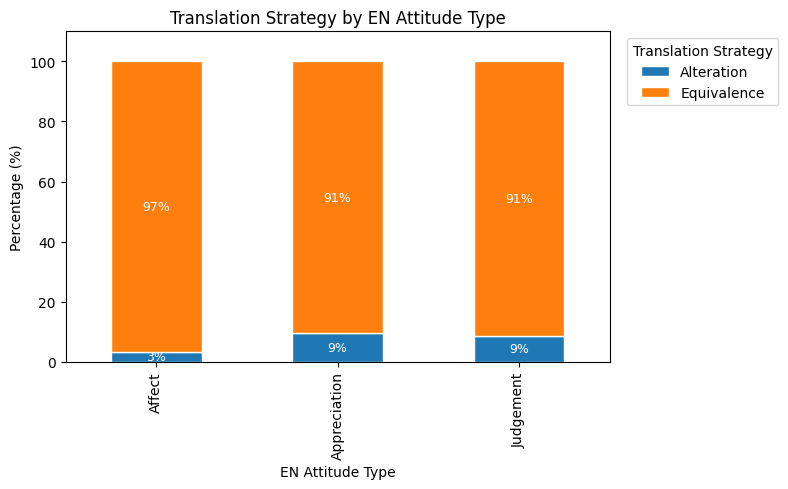


=== Translationese Effect by EN Attitude Type (Raw Counts) ===
Translationese_effect  Explicitation  Implicitation  Total
EN_Attitude_type                                          
Affect                             1              3      4
Appreciation                      65             94    159
Judgement                         14             17     31

=== Translationese Effect by EN Attitude Type (Row %) ===
Translationese_effect  Explicitation  Implicitation
EN_Attitude_type                                   
Affect                          25.0           75.0
Appreciation                    40.9           59.1
Judgement                       45.2           54.8

=== Chi-square: Attitude × Translationese Effect ===
Chi-square = 0.641
df = 2
p = 0.7260
Cramér's V = 0.057

=== Standardized Residuals ===
Translationese_effect  Explicitation  Implicitation
EN_Attitude_type                                   
Affect                         -0.51           0.42
Appreciation            

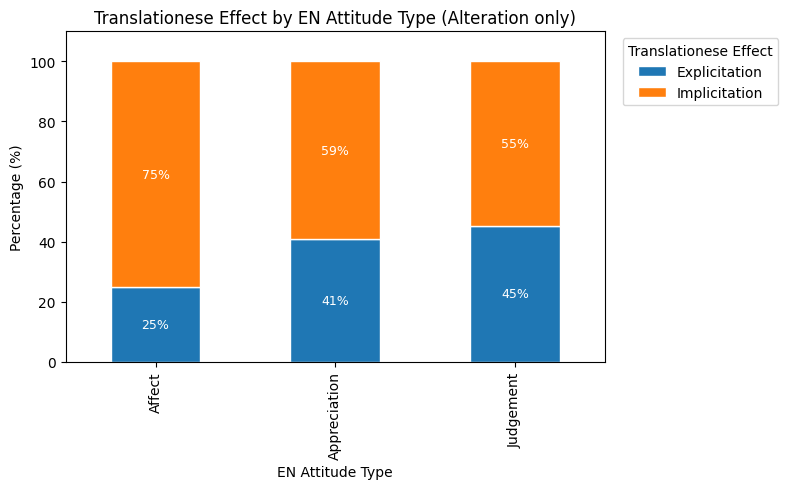

In [24]:
# ============================================================
# Translation Strategy & Translationese Effect by EN Attitude Type
# (excluding Uncertain)
# ============================================================

from scipy.stats import chi2_contingency
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

att_df = core_df[
    core_df["EN_Attitude_type"].isin(["Appreciation", "Judgement", "Affect"])
].copy()

# ============================================================
# 1. Translation Strategy by Attitude Type
# ============================================================

table_ts_att = (
    att_df
    .groupby(["EN_Attitude_type", "Translation_strategy"])
    .size()
    .unstack(fill_value=0)
)

table_ts_att["Total"] = table_ts_att.sum(axis=1)

ts_cols = [c for c in table_ts_att.columns if c != "Total"]

table_ts_att_pct = (
    table_ts_att[ts_cols]
    .div(table_ts_att["Total"], axis=0)
    .mul(100)
    .round(1)
)

print("=== Translation Strategy by EN Attitude Type (Raw Counts) ===")
print(table_ts_att)

print("\n=== Translation Strategy by EN Attitude Type (Row %) ===")
print(table_ts_att_pct)


# ============================================================
# Chi-square
# ============================================================

ct = pd.crosstab(
    att_df["EN_Attitude_type"],
    att_df["Translation_strategy"]
)

chi2, p, dof, expected = chi2_contingency(ct)

n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))

print("\n=== Chi-square: Attitude × Translation Strategy ===")
print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p = {p:.4f}")
print(f"Cramér's V = {cramers_v:.3f}")

# Standardized residuals

std_res = (ct - expected) / np.sqrt(expected)

print("\n=== Standardized Residuals ===")
print(std_res.round(2))


# ============================================================
# Graph
# ============================================================

fig, ax = plt.subplots(figsize=(8,5))

table_ts_att_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    edgecolor="white"
)

ax.set_ylabel("Percentage (%)")
ax.set_xlabel("EN Attitude Type")
ax.set_title("Translation Strategy by EN Attitude Type")
ax.set_ylim(0,110)
ax.legend(title="Translation Strategy",
          bbox_to_anchor=(1.02,1),
          loc="upper left")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f%%",
        label_type="center",
        fontsize=9,
        color="white"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 2. Translationese Effect by Attitude Type
# (Alteration only)
# ============================================================

alt_df = att_df[
    att_df["Translation_strategy"]=="Alteration"
].copy()

table_te_att = (
    alt_df
    .groupby(["EN_Attitude_type","Translationese_effect"])
    .size()
    .unstack(fill_value=0)
)

table_te_att["Total"] = table_te_att.sum(axis=1)

te_cols = [c for c in table_te_att.columns if c != "Total"]

table_te_att_pct = (
    table_te_att[te_cols]
    .div(table_te_att["Total"], axis=0)
    .mul(100)
    .round(1)
)

print("\n=== Translationese Effect by EN Attitude Type (Raw Counts) ===")
print(table_te_att)

print("\n=== Translationese Effect by EN Attitude Type (Row %) ===")
print(table_te_att_pct)


# ============================================================
# Chi-square
# ============================================================

ct2 = pd.crosstab(
    alt_df["EN_Attitude_type"],
    alt_df["Translationese_effect"]
)

chi2, p, dof, expected = chi2_contingency(ct2)

n = ct2.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct2.shape)-1)))

print("\n=== Chi-square: Attitude × Translationese Effect ===")
print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p = {p:.4f}")
print(f"Cramér's V = {cramers_v:.3f}")

std_res = (ct2 - expected) / np.sqrt(expected)

print("\n=== Standardized Residuals ===")
print(std_res.round(2))


# ============================================================
# Graph
# ============================================================

fig, ax = plt.subplots(figsize=(8,5))

table_te_att_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    edgecolor="white"
)

ax.set_ylabel("Percentage (%)")
ax.set_xlabel("EN Attitude Type")
ax.set_title("Translationese Effect by EN Attitude Type (Alteration only)")
ax.set_ylim(0,110)
ax.legend(title="Translationese Effect",
          bbox_to_anchor=(1.02,1),
          loc="upper left")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f%%",
        label_type="center",
        fontsize=9,
        color="white"
    )

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 22.7 MB/s eta 0:00:00
Rows: 2801
Unique talk_id groups: 22
talk_id  n_tokens
  M_Phi       336
  M_Bus       215
  F_Sci       210
  F_Psy       180
  M_Med       170
  M_Art       162
  M_Psy       120
 M_Tech       119
  M_Ent       116
  F_Edu       112
  F_Ent       112
  F_Pol       110
 F_Tech       110
  M_Edu       109
  M_Sci       109
  M_Pol        84
  F_Art        82
  F_His        79
  F_Bus        77
  M_His        72
  F_Med        64
  F_Phi        53

=== Token contribution per talk group ===
talk_id  n_tokens
  M_Phi       336
  M_Bus       215
  F_Sci       210
  F_Psy       180
  M_Med       170
  M_Art       162
  M_Psy       120
 M_Tech       119
  M_Ent       116
  F_Ent       112
  F_Edu       112
 F_Tech       110
  F_Pol       110
  M_Edu       109
  M_Sci       109
  M_Pol        84
  F_Art        82
  F_His        79
  F_Bus        77
  M_His        72
  F_Med        64
  F_Phi        53

Mean tokens pe

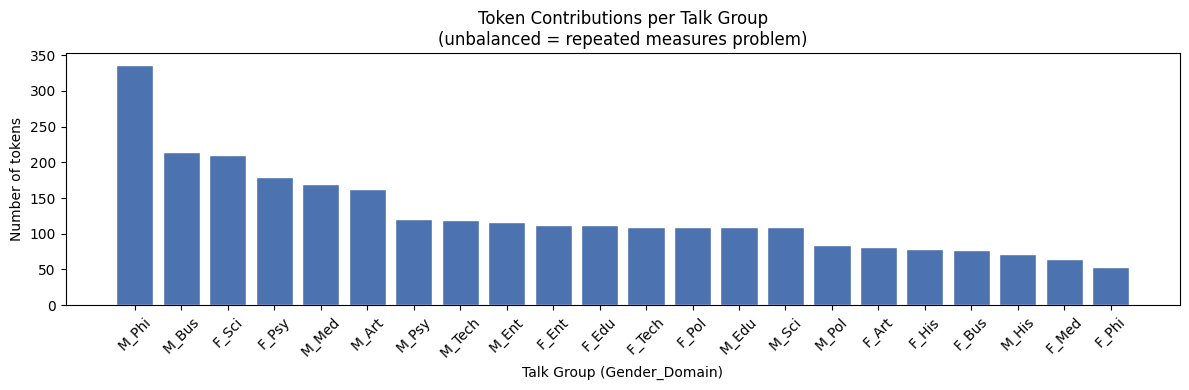


=== Approach A: Aggregated proportions per adjective × talk group ===
    adjective talk_id  Alteration  Equivalence  total  prop_alter
      amazing   F_Art           0            2      2       0.000
      amazing   F_Edu           0            3      3       0.000
      amazing   F_Ent           2            9     11       0.182
      amazing   F_His           1            3      4       0.250
      amazing   F_Phi           1            3      4       0.250
      amazing   F_Pol           3            3      6       0.500
      amazing   F_Psy           1            6      7       0.143
      amazing   F_Sci           3           12     15       0.200
      amazing  F_Tech           2            2      4       0.500
      amazing   M_Art           6           13     19       0.316
      amazing   M_Bus           3            3      6       0.500
      amazing   M_Edu           0            1      1       0.000
      amazing   M_Ent           2           10     12       0.167
     

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



=== Approach B: Mixed-Effects Model (speaker as random intercept) ===
                                Mixed Linear Model Regression Results
Model:                             MixedLM                Dependent Variable:                outcome  
No. Observations:                  2801                   Method:                            ML       
No. Groups:                        22                     Scale:                             0.0864   
Min. group size:                   53                     Log-Likelihood:                    -553.3744
Max. group size:                   336                    Converged:                         Yes      
Mean group size:                   127.3                                                              
------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------

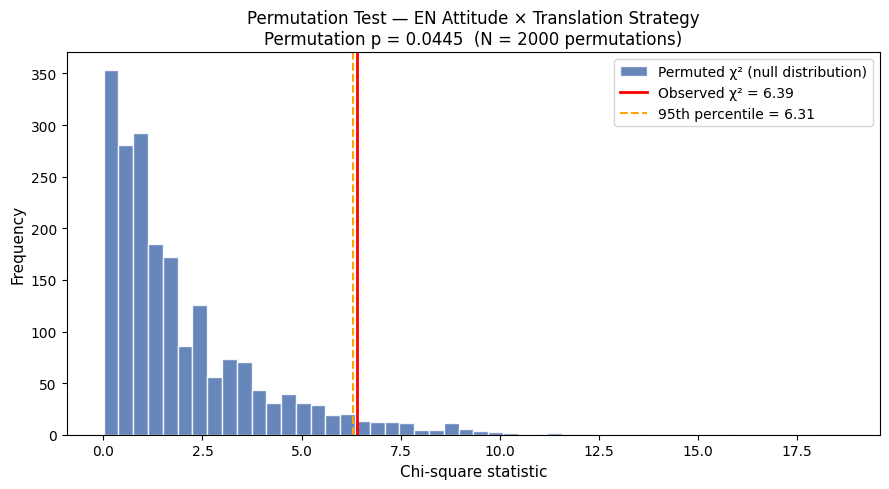


=== Approach D: Type/Token Ratio per Talk Group ===
talk_id  n_tokens  n_types  n_att_types  type_token_ratio
  F_Art        82       12            3             0.146
  F_Bus        77        9            2             0.117
  F_Edu       112       16            3             0.143
  F_Ent       112       15            3             0.134
  F_His        79       14            3             0.177
  F_Med        64       11            3             0.172
  F_Phi        53        8            2             0.151
  F_Pol       110       14            3             0.127
  F_Psy       180       16            3             0.089
  F_Sci       210       14            3             0.067
 F_Tech       110       14            3             0.127
  M_Art       162       16            3             0.099
  M_Bus       215       15            3             0.070
  M_Edu       109       16            3             0.147
  M_Ent       116       16            3             0.138
  M_His        72  

In [ ]:
# ============================================================
# Handling Repeated Measures & Speaker Effects
#
# Problem (Dylan): multiple tokens of the same adjective from
# the same speaker inflate counts and bias chi-square / GLM.
#
# Available grouping variable: Gender + Domain together act as
# a talk-level proxy (each unique Gender×Domain combination
# approximates a speaker group).
#
# NOTE: If Mirela can provide a Speaker_ID or Talk_ID column,
# replace `talk_id` construction below with that column and
# the mixed-effects models will be more precise.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

# Install required libraries
!pip install pymer4 statsmodels -q
# pymer4 wraps R's lme4 — if unavailable, we fall back to
# statsmodels mixed LM which runs in pure Python

# ── 0. Base data ──────────────────────────────────────────────────────────────

me_df = df[
    (df["EN_Evaluative"] != "non-evaluative") &
    (df["EN_Attitude_type"].notna()) &
    (df["EN_Attitude_type"] != "Uncertain") &
    (df["Translation_strategy"].notna()) &
    (df["Gender"].notna()) &
    (df["Domain"].notna())
].copy()

# Construct a talk-level proxy ID from Gender + Domain
# (each unique combination = one speaker group / talk cluster)
# ⚠️  Replace this with an actual Speaker_ID column if Mirela provides one
me_df["talk_id"] = me_df["Gender"].astype(str) + "_" + me_df["Domain"].astype(str)

print(f"Rows: {len(me_df)}")
print(f"Unique talk_id groups: {me_df['talk_id'].nunique()}")
print(me_df["talk_id"].value_counts().rename_axis("talk_id").reset_index(name="n_tokens").to_string(index=False))


# ── 1. DIAGNOSE: How unbalanced are speaker contributions? ───────────────────

tok_per_talk = me_df.groupby("talk_id").size().reset_index(name="n_tokens")
tok_per_talk = tok_per_talk.sort_values("n_tokens", ascending=False)

print("\n=== Token contribution per talk group ===")
print(tok_per_talk.to_string(index=False))
print(f"\nMean tokens per group : {tok_per_talk['n_tokens'].mean():.1f}")
print(f"SD                    : {tok_per_talk['n_tokens'].std():.1f}")
print(f"Min / Max             : {tok_per_talk['n_tokens'].min()} / {tok_per_talk['n_tokens'].max()}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(tok_per_talk["talk_id"], tok_per_talk["n_tokens"],
       color="#4C72B0", edgecolor="white")
ax.set_title("Token Contributions per Talk Group\n(unbalanced = repeated measures problem)",
             fontsize=12)
ax.set_xlabel("Talk Group (Gender_Domain)", fontsize=10)
ax.set_ylabel("Number of tokens", fontsize=10)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("graph_speaker_token_distribution.png", dpi=300)
plt.show()


# ── 2. APPROACH A — Aggregation (type-level, not token-level) ─────────────────
# Collapse to one row per adjective × talk_id combination.
# Uses proportions instead of raw counts — removes the bias
# from high-frequency speakers without needing mixed models.

agg_df = (
    me_df.groupby(["adjective", "talk_id", "EN_Attitude_type", "Translation_strategy"])
    .size()
    .reset_index(name="n")
)

# Proportion of Alteration per adjective × talk group
agg_strat = (
    me_df.groupby(["adjective", "talk_id", "Translation_strategy"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
if "Alteration" in agg_strat.columns and "Equivalence" in agg_strat.columns:
    agg_strat["total"]        = agg_strat["Alteration"] + agg_strat["Equivalence"]
    agg_strat["prop_alter"]   = agg_strat["Alteration"] / agg_strat["total"]

print("\n=== Approach A: Aggregated proportions per adjective × talk group ===")
print(agg_strat.round(3).to_string(index=False))


# ── 3. APPROACH B — Mixed-Effects Logistic Regression ────────────────────────
# Outcome    : Translation_strategy (Alteration = 1, Equivalence = 0)
# Fixed effect : EN_Attitude_type
# Random effect: talk_id (= speaker/talk cluster)
# This directly addresses Dylan's concern.

try:
    import statsmodels.formula.api as smf

    me_df["outcome"] = (me_df["Translation_strategy"] == "Alteration").astype(int)

    # Encode EN_Attitude_type as dummy (reference = Appreciation)
    me_df["EN_Att_enc"] = pd.Categorical(
        me_df["EN_Attitude_type"],
        categories=["Appreciation", "Judgement", "Affect"]
    ).codes  # 0=Appreciation, 1=Judgement, 2=Affect

    # Mixed-effects logistic regression
    # groups = talk_id (random intercept per speaker group)
    mixedlm = smf.mixedlm(
        "outcome ~ C(EN_Attitude_type, Treatment('Appreciation'))",
        data=me_df,
        groups=me_df["talk_id"]
    ).fit(reml=False)

    print("\n=== Approach B: Mixed-Effects Model (speaker as random intercept) ===")
    print(mixedlm.summary())

    # Extract fixed effects table
    fe = mixedlm.fe_params.reset_index()
    fe.columns = ["Term", "Coefficient"]
    fe["SE"]      = mixedlm.bse_fe.values
    fe["z"]       = mixedlm.tvalues.values
    fe["p-value"] = mixedlm.pvalues.values
    fe["Sig"]     = fe["p-value"].apply(
        lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    )

    print("\n=== Fixed Effects Summary ===")
    print(fe.round(4).to_string(index=False))

    # Random effects variance — how much speaker matters
    print(f"\nRandom effect variance (talk_id): {mixedlm.cov_re.values[0][0]:.4f}")
    print("(Larger = speaker contributes more unexplained variance)")

except Exception as e:
    print(f"\nMixed-effects model error: {e}")
    print("Falling back to Approach C (permutation test).")


# ── 4. APPROACH C — Permutation Test (non-parametric, speaker-robust) ─────────
# Shuffles EN_Attitude_type labels within each talk_id group
# (preserving the speaker's total token count) and recomputes
# chi-square. Compares observed chi-square to null distribution.
# Robust to both repeated measures and unbalanced speakers.

print("\n=== Approach C: Permutation Test (EN Attitude × Translation Strategy) ===")

observed_ct = pd.crosstab(me_df["EN_Attitude_type"], me_df["Translation_strategy"])
observed_chi2, _, _, _ = chi2_contingency(observed_ct)
print(f"Observed chi-square: {observed_chi2:.3f}")

N_PERM = 2000
perm_chi2s = []

for _ in range(N_PERM):
    # Shuffle EN_Attitude_type within each talk_id (preserves speaker structure)
    shuffled = (
        me_df.groupby("talk_id")["EN_Attitude_type"]
        .transform(lambda x: x.sample(frac=1).values)
    )
    perm_ct = pd.crosstab(shuffled, me_df["Translation_strategy"])
    if perm_ct.shape[0] >= 2 and perm_ct.shape[1] >= 2:
        c2, _, _, _ = chi2_contingency(perm_ct)
        perm_chi2s.append(c2)

perm_chi2s = np.array(perm_chi2s)
p_perm     = (perm_chi2s >= observed_chi2).mean()

print(f"Permutation p-value (N={N_PERM}): {p_perm:.4f}")
print(f"Significant (p < .05): {'Yes' if p_perm < 0.05 else 'No'}")

# Plot null distribution
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.hist(perm_chi2s, bins=50, color="#4C72B0", edgecolor="white", alpha=0.85,
         label="Permuted χ² (null distribution)")
ax2.axvline(observed_chi2, color="red", linewidth=2,
            label=f"Observed χ² = {observed_chi2:.2f}")
ax2.axvline(np.percentile(perm_chi2s, 95), color="orange",
            linewidth=1.5, linestyle="--",
            label=f"95th percentile = {np.percentile(perm_chi2s, 95):.2f}")
ax2.set_title(
    f"Permutation Test — EN Attitude × Translation Strategy\n"
    f"Permutation p = {p_perm:.4f}  (N = {N_PERM} permutations)",
    fontsize=12
)
ax2.set_xlabel("Chi-square statistic", fontsize=11)
ax2.set_ylabel("Frequency", fontsize=11)
ax2.legend(fontsize=10)
plt.tight_layout()
plt.savefig("graph_permutation_test.png", dpi=300)
plt.show()


# ── 5. APPROACH D — Type/Token ratio per adjective × talk group ───────────────
# Shows how many distinct adjective types each talk group contributes
# vs. raw token count — directly quantifies the repeated measures problem.

ttr = (
    me_df.groupby("talk_id")
    .agg(
        n_tokens    = ("adjective", "count"),
        n_types     = ("adjective", "nunique"),
        n_att_types = ("EN_Attitude_type", "nunique")
    )
    .reset_index()
)
ttr["type_token_ratio"] = (ttr["n_types"] / ttr["n_tokens"]).round(3)

print("\n=== Approach D: Type/Token Ratio per Talk Group ===")
print(ttr.to_string(index=False))
print("\n(TTR close to 1.0 = diverse; close to 0 = dominated by one adjective)")


# ── 6. COMPARISON TABLE — naive chi-sq vs permutation ────────────────────────

print("\n=== Summary: Naive vs Speaker-Robust Results ===")
naive_ct   = pd.crosstab(me_df["EN_Attitude_type"], me_df["Translation_strategy"])
naive_chi2, naive_p, naive_dof, _ = chi2_contingency(naive_ct)
n          = naive_ct.values.sum()
naive_cv   = np.sqrt(naive_chi2 / (n * (min(naive_ct.shape) - 1)))

summary = pd.DataFrame([
    {
        "Method":          "Naive chi-square (ignores speaker)",
        "Chi-square":      round(naive_chi2, 3),
        "p-value":         round(naive_p, 4),
        "Cramér's V":      round(naive_cv, 4),
        "Speaker-robust":  "No"
    },
    {
        "Method":          f"Permutation test (within-speaker shuffle, N={N_PERM})",
        "Chi-square":      round(observed_chi2, 3),
        "p-value":         round(p_perm, 4),
        "Cramér's V":      "—",
        "Speaker-robust":  "Yes"
    },
])
print(summary.to_string(index=False))

=== Overall Translation Strategy Distribution ===
Translation_Strategy  Count  Percentage
         Equivalence   2545       89.83
          Alteration    271        9.57
                 NaN     17        0.60

=== Translationese Effects (within Alteration cases only) ===
Translationese_Effect  Count  Percentage
        Implicitation    181       66.79
        Explicitation     89       32.84
                  NaN      1        0.37

=== Translation Strategy per Adjective (Raw Counts) ===
    adjective  Alteration  Equivalence  Total
      amazing          34           89    123
          bad          22          220    242
    beautiful           3           66     69
     creative           1           41     42
    different          38          352    390
    difficult           7           56     63
extraordinary           7           26     33
    fantastic           3           22     25
  fascinating           1           26     27
         good          73          658    731


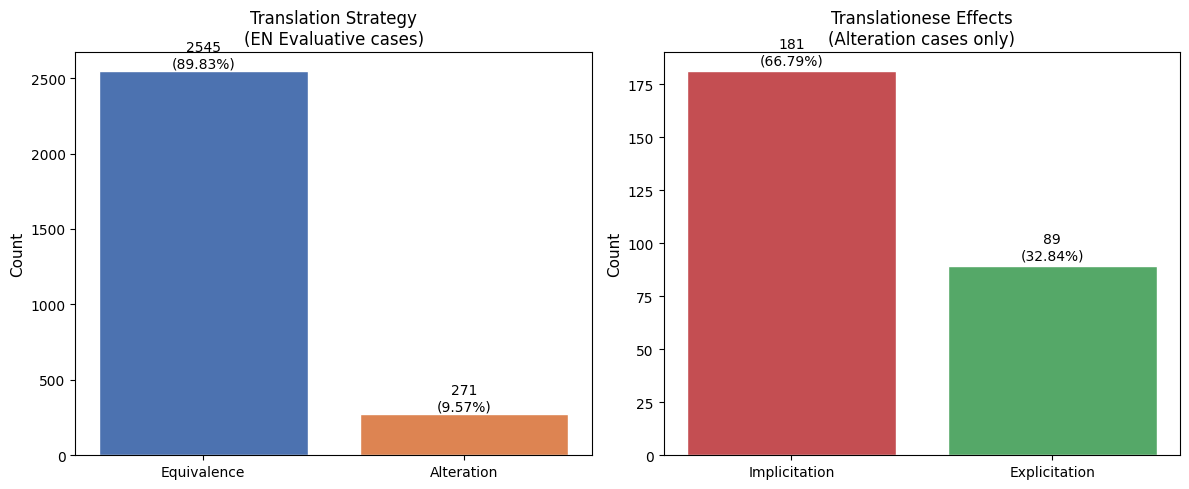

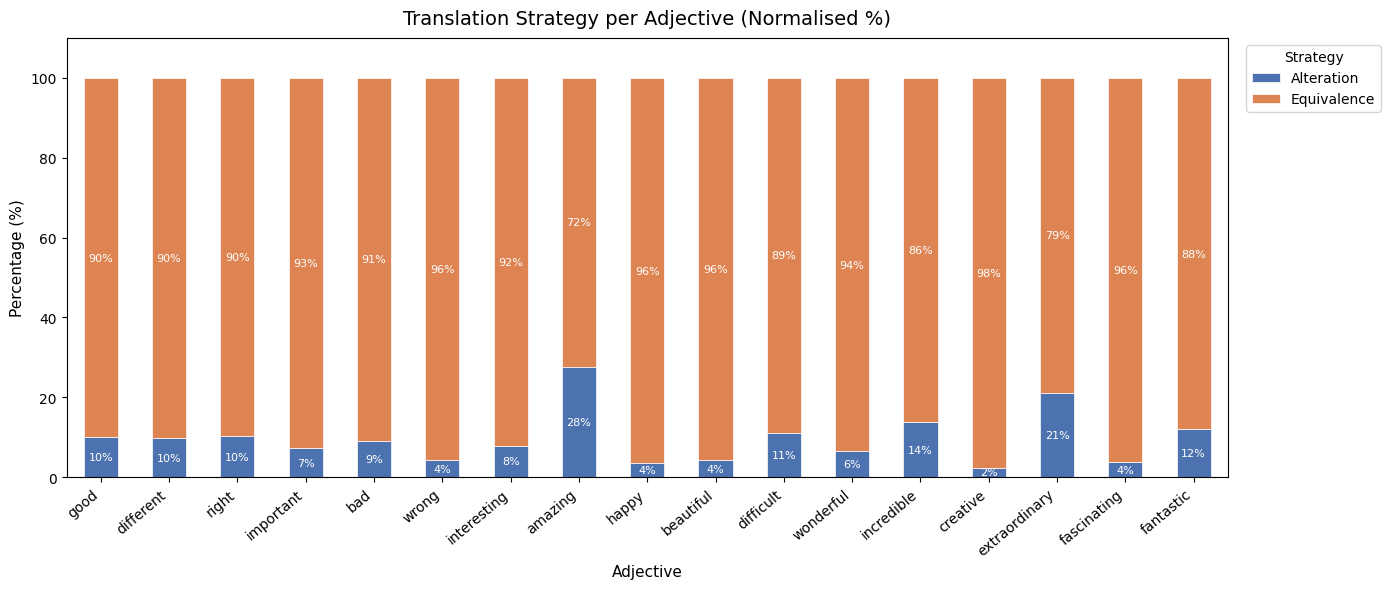

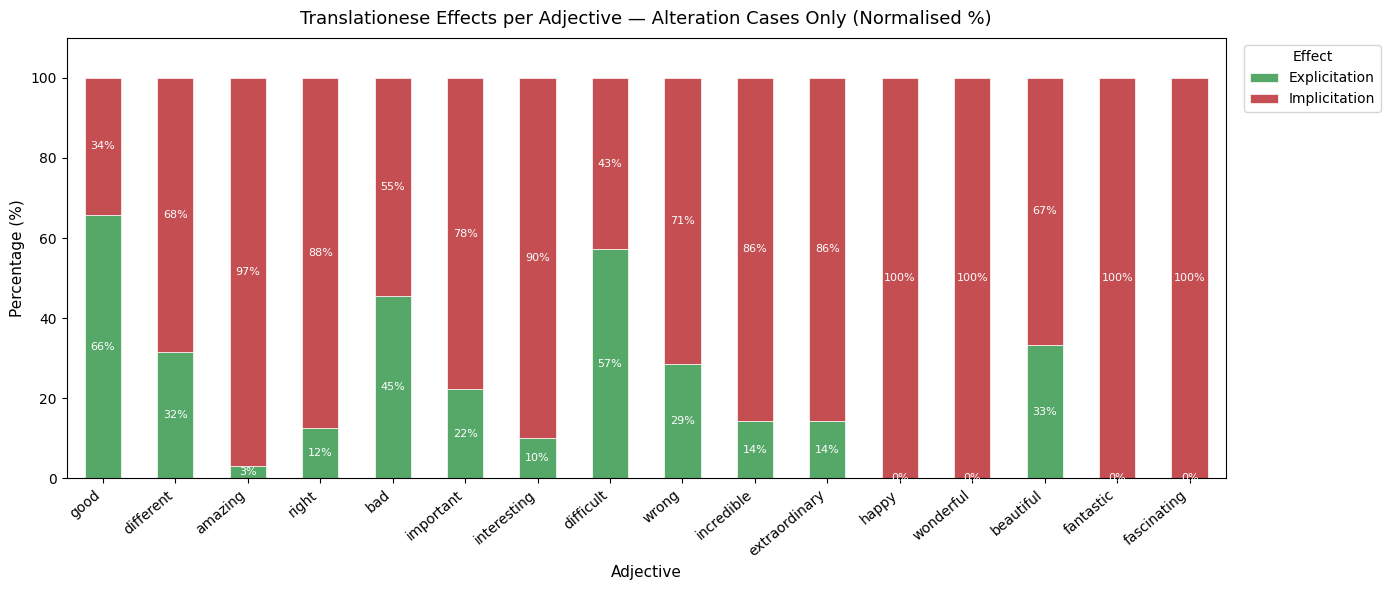

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ts_df = df[df["EN_Evaluative"] != "non-evaluative"].copy()

# ── 1. Overall Translation Strategy (Equivalence vs Alteration) ──────────────

table_ts = (
    ts_df["Translation_strategy"]
    .value_counts(dropna=False)
    .rename_axis("Translation_Strategy")
    .reset_index(name="Count")
)
table_ts["Percentage"] = (
    table_ts["Count"] / table_ts["Count"].sum() * 100
).round(2)

print("=== Overall Translation Strategy Distribution ===")
print(table_ts.to_string(index=False))

# ── 2. Translationese Effects within Alteration cases only ───────────────────

alteration_df = ts_df[ts_df["Translation_strategy"] == "Alteration"].copy()

table_te = (
    alteration_df["Translationese_effect"]
    .value_counts(dropna=False)
    .rename_axis("Translationese_Effect")
    .reset_index(name="Count")
)
table_te["Percentage"] = (
    table_te["Count"] / table_te["Count"].sum() * 100
).round(2)

print("\n=== Translationese Effects (within Alteration cases only) ===")
print(table_te.to_string(index=False))

# ── 3. Per-adjective breakdown: Translation Strategy ─────────────────────────

ts_per_adj = (
    ts_df
    .groupby(["adjective", "Translation_strategy"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
ts_per_adj["Total"] = ts_per_adj.drop(columns="adjective").sum(axis=1)

print("\n=== Translation Strategy per Adjective (Raw Counts) ===")
print(ts_per_adj.to_string(index=False))

ts_cols = [c for c in ts_per_adj.columns if c not in ("adjective", "Total")]
ts_pct = ts_per_adj[["adjective", "Total"]].copy()
for col in ts_cols:
    ts_pct[col + "_%"] = (ts_per_adj[col] / ts_per_adj["Total"] * 100).round(1)

print("\n=== Translation Strategy per Adjective (Row %) ===")
print(ts_pct.to_string(index=False))

# ── 4. Per-adjective breakdown: Translationese Effects (Alteration only) ─────

te_per_adj = (
    alteration_df
    .groupby(["adjective", "Translationese_effect"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
te_per_adj["Total_Alteration"] = te_per_adj.drop(columns="adjective").sum(axis=1)

print("\n=== Translationese Effects per Adjective — Alteration cases only (Raw Counts) ===")
print(te_per_adj.to_string(index=False))

te_cols = [c for c in te_per_adj.columns if c not in ("adjective", "Total_Alteration")]
te_pct = te_per_adj[["adjective", "Total_Alteration"]].copy()
for col in te_cols:
    te_pct[col + "_%"] = (te_per_adj[col] / te_per_adj["Total_Alteration"] * 100).round(1)

print("\n=== Translationese Effects per Adjective (Row %) ===")
print(te_pct.to_string(index=False))

# ── 5. CHARTS ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart A: Overall Translation Strategy
ts_clean = table_ts[table_ts["Translation_Strategy"].notna()]
bars = axes[0].bar(
    ts_clean["Translation_Strategy"],
    ts_clean["Count"],
    color=["#4C72B0", "#DD8452"],
    edgecolor="white"
)
for bar, row in zip(bars, ts_clean.itertuples()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{row.Count}\n({row.Percentage}%)",
        ha="center", va="bottom", fontsize=10
    )
axes[0].set_title("Translation Strategy\n(EN Evaluative cases)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_xlabel("")

# Chart B: Translationese Effects (Alteration only)
te_clean = table_te[table_te["Translationese_Effect"].notna()]
bars2 = axes[1].bar(
    te_clean["Translationese_Effect"],
    te_clean["Count"],
    color=["#C44E52","#55A868"],
    edgecolor="white"
)
for bar, row in zip(bars2, te_clean.itertuples()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{row.Count}\n({row.Percentage}%)",
        ha="center", va="bottom", fontsize=10
    )
axes[1].set_title("Translationese Effects\n(Alteration cases only)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("graph_translation_strategy_effects.png", dpi=300)
plt.show()

# Chart C: Normalised stacked bar — Translation Strategy per adjective
ts_plot = ts_per_adj.set_index("adjective")[ts_cols]
ts_plot = ts_plot.loc[
    ts_per_adj.set_index("adjective")["Total"].sort_values(ascending=False).index
]
ts_plot_pct = ts_plot.div(ts_plot.sum(axis=1), axis=0) * 100

ax = ts_plot_pct.plot(
    kind="bar", stacked=True, figsize=(14, 6),
    color=["#4C72B0", "#DD8452"][:len(ts_cols)],
    edgecolor="white", linewidth=0.5
)
ax.set_title("Translation Strategy per Adjective (Normalised %)", fontsize=14, pad=10)
ax.set_xlabel("Adjective", fontsize=11)
ax.set_ylabel("Percentage (%)", fontsize=11)
ax.set_xticklabels(ts_plot_pct.index, rotation=40, ha="right", fontsize=10)
ax.legend(title="Strategy", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
ax.set_ylim(0, 110)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=8, color="white")
plt.tight_layout()
plt.savefig("graph_translation_strategy_per_adjective.png", dpi=300)
plt.show()

# Chart D: Normalised stacked bar — Translationese Effects per adjective (Alteration only)
if len(te_cols) >= 2:
    te_plot = te_per_adj.set_index("adjective")[te_cols]
    te_plot = te_plot.loc[
        te_per_adj.set_index("adjective")["Total_Alteration"].sort_values(ascending=False).index
    ]
    te_plot_pct = te_plot.div(te_plot.sum(axis=1), axis=0) * 100

    ax2 = te_plot_pct.plot(
        kind="bar", stacked=True, figsize=(14, 6),
        color=["#55A868", "#C44E52"],
        edgecolor="white", linewidth=0.5
    )
    ax2.set_title("Translationese Effects per Adjective — Alteration Cases Only (Normalised %)",
                  fontsize=13, pad=10)
    ax2.set_xlabel("Adjective", fontsize=11)
    ax2.set_ylabel("Percentage (%)", fontsize=11)
    ax2.set_xticklabels(te_plot_pct.index, rotation=40, ha="right", fontsize=10)
    ax2.legend(title="Effect", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    ax2.set_ylim(0, 110)
    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=8, color="white")
    plt.tight_layout()
    plt.savefig("graph_translationese_effects_per_adjective.png", dpi=300)
    plt.show()

##Loglinear

Poisson regression approximation of loglinear models

# NEED TO CHECK THE IMPLEMENTATION AND RESULTS


In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ----------------------------
# 1. Clean data
# ----------------------------
df_ll = df.dropna(
    subset=[
        "EN_Attitude_type",
        "DE_Attitude_type",
        "Translation_strategy",
        "Translationese_effect",
        "Gender",
        "Domain"
    ]
).copy()

# ----------------------------
# 2. Create frequency table
# ----------------------------
freq = (
    df_ll
    .groupby([
        "EN_Attitude_type",
        "DE_Attitude_type",
        "Translation_strategy",
        "Translationese_effect",
        "Gender",
        "Domain"
    ])
    .size()
    .reset_index(name="freq")
)

# ----------------------------
# 3. Model 1 (main effects)
# ----------------------------
model_1 = smf.glm(
    formula="""
        freq ~ EN_Attitude_type
             + DE_Attitude_type
             + Translation_strategy
             + Translationese_effect
             + Gender
             + Domain
    """,
    data=freq,
    family=sm.families.Poisson()
).fit()

print("\n===== MODEL 1 SUMMARY =====\n")
print(model_1.summary())

# ----------------------------
# 4. Model 2 (interactions)
# ----------------------------
model_2 = smf.glm(
    formula="""
        freq ~ EN_Attitude_type * DE_Attitude_type
             + EN_Attitude_type * Translation_strategy
             + DE_Attitude_type * Translation_strategy
             + Translation_strategy * Translationese_effect
             + Gender
             + Domain
    """,
    data=freq,
    family=sm.families.Poisson()
).fit()

print("\n===== MODEL 2 SUMMARY =====\n")
print(model_2.summary())

# ----------------------------
# 5. Likelihood Ratio Test (correct way)
# ----------------------------
import scipy.stats as stats

lr_stat = 2 * (model_2.llf - model_1.llf)
df_diff = model_2.df_model - model_1.df_model

p_value = stats.chi2.sf(lr_stat, df_diff)

print("\n===== LR TEST =====")
print("Likelihood Ratio:", lr_stat)
print("df difference:", df_diff)
print("p-value:", p_value)

# ----------------------------
# 6. Overdispersion check (important!)
# ----------------------------
dispersion = model_1.deviance / model_1.df_resid

print("\n===== OVERDISPERSION CHECK =====")
print("Dispersion (deviance / df_resid):", dispersion)

if dispersion > 2:
    print("Strong overdispersion detected → consider Negative Binomial model")
else:
    print("Poisson assumption is reasonably OK")


===== MODEL 1 SUMMARY =====

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   freq   No. Observations:                   65
Model:                            GLM   Df Residuals:                       47
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -111.79
Date:                Tue, 09 Jun 2026   Deviance:                       43.046
Time:                        12:51:05   Pearson chi2:                     44.1
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5013
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

# Translation Strategy & Translationese Effects Distribution

GENDER × EN ATTITUDE TYPE

Contingency Table (counts):
EN_Attitude_type  Affect  Appreciation  Judgement
Gender                                           
F                     44           969        181
M                     83          1269        267

Row percentages (%):
EN_Attitude_type  Affect  Appreciation  Judgement
Gender                                           
F                    3.7          81.2       15.2
M                    5.1          78.4       16.5

Chi-square = 4.594, df = 2, p = 0.1006
Cramér's V = 0.0404  (~0.1 small, ~0.3 moderate, ~0.5 large)

Adjusted Standardised Residuals (|> 1.96| = significant at p < .05):
EN_Attitude_type  Affect  Appreciation  Judgement
Gender                                           
F                  -1.82           1.8      -0.95
M                   1.82          -1.8       0.95


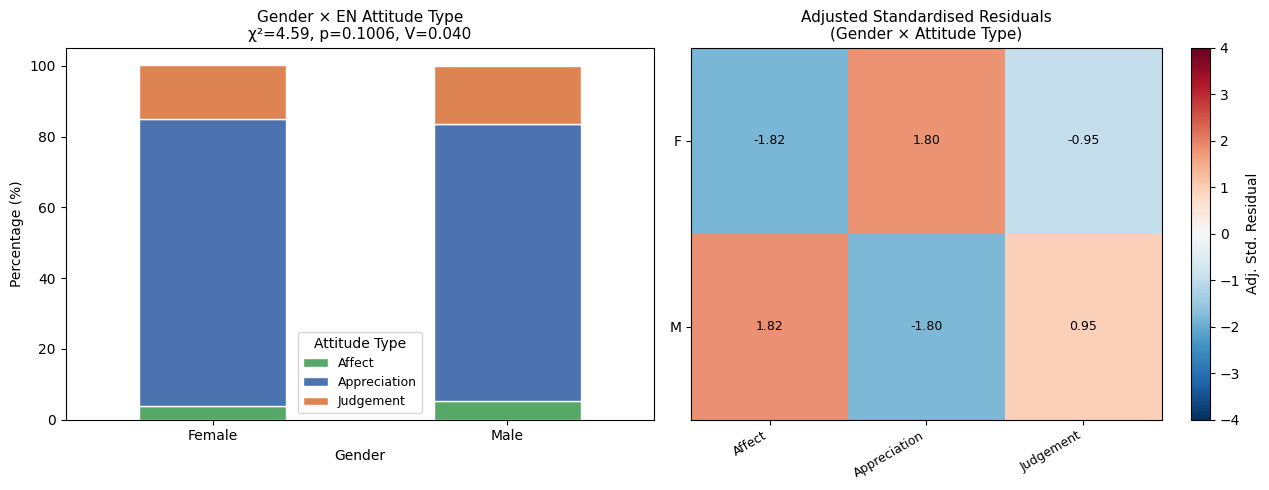


DOMAIN × EN ATTITUDE TYPE

Contingency Table (counts):
EN_Attitude_type  Affect  Appreciation  Judgement
Domain                                           
Art                    4           181         60
Bus                   27           225         41
Edu                    5           171         46
Ent                   19           179         31
His                    1           125         26
Med                   18           194         24
Phi                   11           322         56
Pol                    4           161         31
Psy                   27           206         67
Sci                    7           278         36
Tech                   4           196         30

Row percentages (%):
EN_Attitude_type  Affect  Appreciation  Judgement
Domain                                           
Art                  1.6          73.9       24.5
Bus                  9.2          76.8       14.0
Edu                  2.3          77.0       20.7
Ent                  8

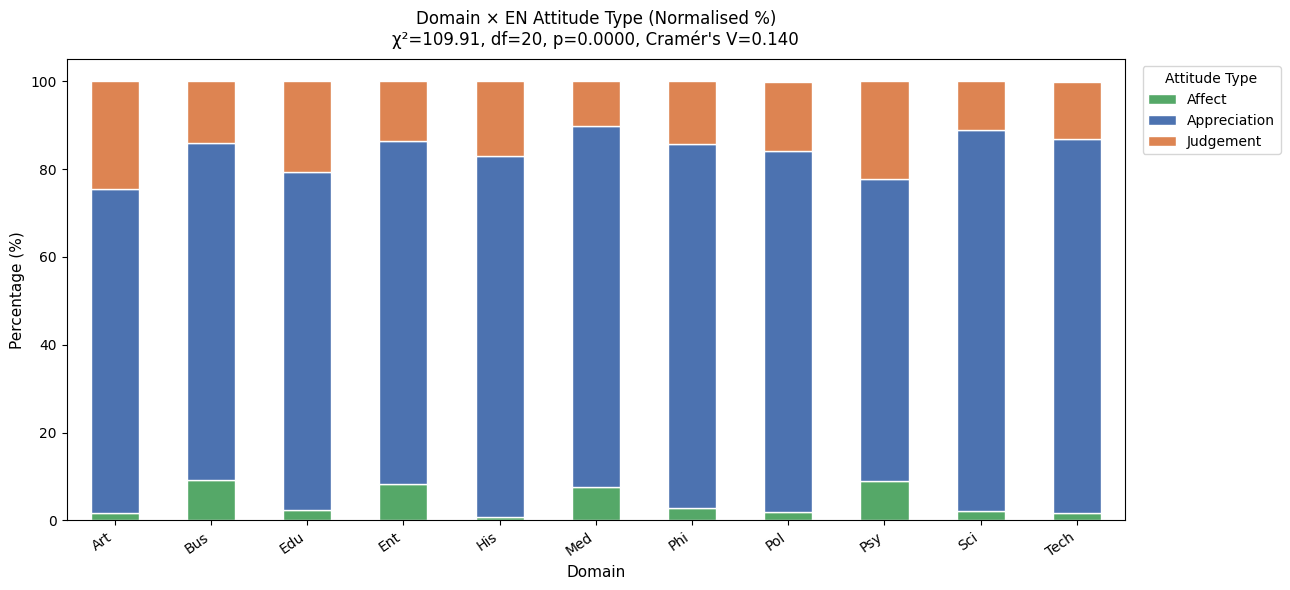

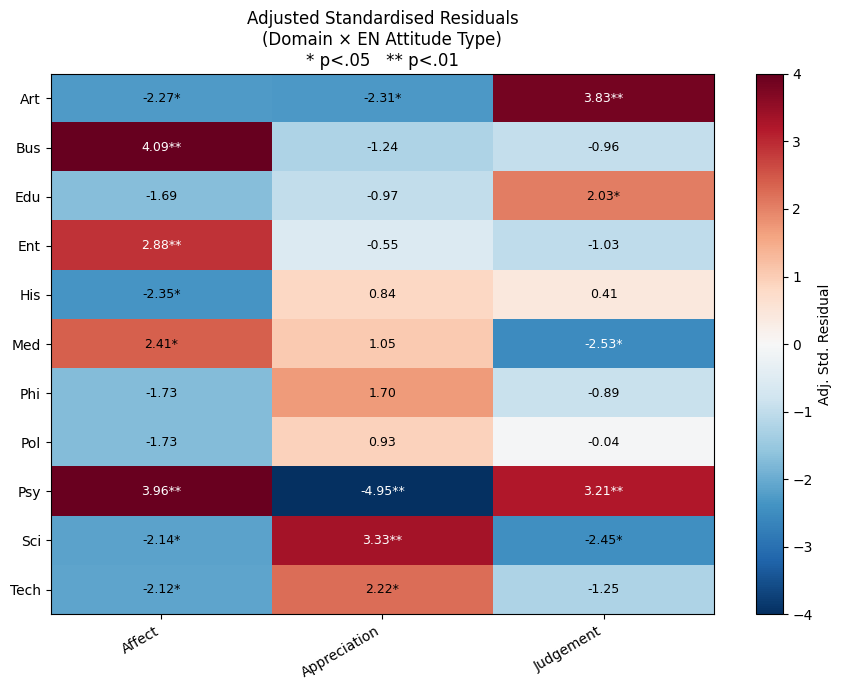


SUMMARY: Statistical Significance of Effects on EN Attitude Type
Factor  Chi-square  df  p-value  Cramér's V Significant Effect size
Gender       4.594   2   0.1006      0.0404          No       Small
Domain     109.911  20   0.0000      0.1398         Yes       Small


In [ ]:
# ============================================================
# Domain & Gender Effects on EN Attitude Type
# Significance testing with chi-square + Cramér's V
# Post-hoc: adjusted standardised residuals
# ============================================================
import numpy as np
from scipy.stats import chi2_contingency

# Work from EN evaluative rows only, drop Uncertain (too few for reliable testing)
stat_df = df[
    (df["EN_Evaluative"] != "non-evaluative") &
    (df["EN_Attitude_type"].notna()) &
    (df["EN_Attitude_type"] != "Uncertain")
].copy()

def cramers_v(chi2, n, k):
    """Cramér's V effect size. k = min(rows, cols) of contingency table."""
    return np.sqrt(chi2 / (n * (k - 1)))

def adjusted_residuals(observed, expected):
    """Adjusted standardised residuals for post-hoc cell-level interpretation."""
    row_totals = observed.sum(axis=1).values[:, None]
    col_totals = observed.sum(axis=0).values[None, :]
    n = observed.values.sum()
    std_res = (observed.values - expected) / np.sqrt(
        expected
        * (1 - row_totals / n)
        * (1 - col_totals / n)
    )
    return pd.DataFrame(std_res, index=observed.index, columns=observed.columns)

# --- CHART: Grouped stacked bar chart ---
plot_data = en_att_per_adj.set_index("adjective")[att_cols]

# Sort adjectives by total for readability
plot_data = plot_data.loc[
    en_att_per_adj.set_index("adjective")["Total_Evaluative"].sort_values(ascending=False).index
]

# ── 1. GENDER × EN ATTITUDE TYPE ─────────────────────────────────────────────

colors = {"Appreciation": "#4C72B0", "Judgement": "#DD8452", "Affect": "#55A868", "Uncertain": "#C44E52"}
bar_colors = [colors.get(c, "#888888") for c in plot_data.columns]
print("=" * 60)
print("GENDER × EN ATTITUDE TYPE")
print("=" * 60)

ct_gender = pd.crosstab(stat_df["Gender"], stat_df["EN_Attitude_type"])
print("\nContingency Table (counts):")
print(ct_gender)

ct_gender_pct = ct_gender.div(ct_gender.sum(axis=1), axis=0).mul(100).round(1)
print("\nRow percentages (%):")
print(ct_gender_pct)

chi2_g, p_g, dof_g, expected_g = chi2_contingency(ct_gender)
n_g = ct_gender.values.sum()
cv_g = cramers_v(chi2_g, n_g, min(ct_gender.shape))

print(f"\nChi-square = {chi2_g:.3f}, df = {dof_g}, p = {p_g:.4f}")
print(f"Cramér's V = {cv_g:.4f}  (~0.1 small, ~0.3 moderate, ~0.5 large)")

print("\nAdjusted Standardised Residuals (|> 1.96| = significant at p < .05):")
adj_res_g = adjusted_residuals(ct_gender, expected_g)
print(adj_res_g.round(2))

# --- CHART: Gender × EN Attitude type ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_gender_pct.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[colors.get(c, "#888") for c in ct_gender_pct.columns],
    edgecolor="white"
)
axes[0].set_title(f"Gender × EN Attitude Type\nχ²={chi2_g:.2f}, p={p_g:.4f}, V={cv_g:.3f}", fontsize=11)
axes[0].set_xlabel("Gender", fontsize=10)
axes[0].set_ylabel("Percentage (%)", fontsize=10)
axes[0].set_xticklabels(["Female", "Male"], rotation=0)
axes[0].legend(title="Attitude Type", fontsize=9)

# Heatmap of adjusted residuals
im = axes[1].imshow(adj_res_g.values, cmap="RdBu_r", aspect="auto", vmin=-4, vmax=4)
axes[1].set_xticks(range(len(adj_res_g.columns)))
axes[1].set_xticklabels(adj_res_g.columns, rotation=30, ha="right", fontsize=9)
axes[1].set_yticks(range(len(adj_res_g.index)))
axes[1].set_yticklabels(adj_res_g.index, fontsize=10)
axes[1].set_title("Adjusted Standardised Residuals\n(Gender × Attitude Type)", fontsize=11)
plt.colorbar(im, ax=axes[1], label="Adj. Std. Residual")

for i in range(adj_res_g.shape[0]):
    for j in range(adj_res_g.shape[1]):
        val = adj_res_g.values[i, j]
        marker = "*" if abs(val) > 1.96 else ""
        axes[1].text(j, i, f"{val:.2f}{marker}", ha="center", va="center", fontsize=9,
                     color="white" if abs(val) > 2.5 else "black")

plt.tight_layout()
plt.savefig("graph_gender_attitude_type.png", dpi=300)
plt.show()


# ── 2. DOMAIN × EN ATTITUDE TYPE ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("DOMAIN × EN ATTITUDE TYPE")
print("=" * 60)

ct_domain = pd.crosstab(stat_df["Domain"], stat_df["EN_Attitude_type"])
print("\nContingency Table (counts):")
print(ct_domain)

ct_domain_pct = ct_domain.div(ct_domain.sum(axis=1), axis=0).mul(100).round(1)
print("\nRow percentages (%):")
print(ct_domain_pct)

chi2_d, p_d, dof_d, expected_d = chi2_contingency(ct_domain)
n_d = ct_domain.values.sum()
cv_d = cramers_v(chi2_d, n_d, min(ct_domain.shape))

print(f"\nChi-square = {chi2_d:.3f}, df = {dof_d}, p = {p_d:.4f}")
print(f"Cramér's V = {cv_d:.4f}  (~0.1 small, ~0.3 moderate, ~0.5 large)")

print("\nAdjusted Standardised Residuals (|> 1.96| = p < .05, |> 2.58| = p < .01):")
adj_res_d = adjusted_residuals(ct_domain, expected_d)
print(adj_res_d.round(2))

# --- CHART: Domain × EN Attitude type (normalised stacked bar) ---
fig2, ax4 = plt.subplots(figsize=(13, 6))

ct_domain_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax4,
    color=[colors.get(c, "#888") for c in ct_domain_pct.columns],
    edgecolor="white"
)
ax4.set_title(
    f"Domain × EN Attitude Type (Normalised %)\nχ²={chi2_d:.2f}, df={dof_d}, p={p_d:.4f}, Cramér's V={cv_d:.3f}",
    fontsize=12, pad=10
)
ax4.set_xlabel("Domain", fontsize=11)
ax4.set_ylabel("Percentage (%)", fontsize=11)
ax4.set_xticklabels(ct_domain_pct.index, rotation=35, ha="right", fontsize=10)
ax4.legend(title="Attitude Type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("graph_domain_attitude_type.png", dpi=300)
plt.show()

# --- CHART: Adjusted residuals heatmap for domain ---
fig3, ax5 = plt.subplots(figsize=(9, 7))

im2 = ax5.imshow(adj_res_d.values, cmap="RdBu_r", aspect="auto", vmin=-4, vmax=4)
ax5.set_xticks(range(len(adj_res_d.columns)))
ax5.set_xticklabels(adj_res_d.columns, rotation=30, ha="right", fontsize=10)
ax5.set_yticks(range(len(adj_res_d.index)))
ax5.set_yticklabels(adj_res_d.index, fontsize=10)
ax5.set_title(
    "Adjusted Standardised Residuals\n(Domain × EN Attitude Type)\n* p<.05   ** p<.01",
    fontsize=12
)
plt.colorbar(im2, ax=ax5, label="Adj. Std. Residual")

for i in range(adj_res_d.shape[0]):
    for j in range(adj_res_d.shape[1]):
        val = adj_res_d.values[i, j]
        if abs(val) > 2.58:
            marker = "**"
        elif abs(val) > 1.96:
            marker = "*"
        else:
            marker = ""
        ax5.text(j, i, f"{val:.2f}{marker}", ha="center", va="center", fontsize=9,
                 color="white" if abs(val) > 2.5 else "black")

plt.tight_layout()
plt.savefig("graph_domain_attitude_residuals.png", dpi=300)
plt.show()


# ── 3. COMBINED SUMMARY TABLE ─────────────────────────────────────────────────

print("\n" + "=" * 60)
print("SUMMARY: Statistical Significance of Effects on EN Attitude Type")
print("=" * 60)
summary = pd.DataFrame([
    {
        "Factor":      "Gender",
        "Chi-square":  round(chi2_g, 3),
        "df":          dof_g,
        "p-value":     round(p_g, 4),
        "Cramér's V":  round(cv_g, 4),
        "Significant": "Yes" if p_g < 0.05 else "No",
        "Effect size": "Large" if cv_g >= 0.5 else "Moderate" if cv_g >= 0.3 else "Small"
    },
    {
        "Factor":      "Domain",
        "Chi-square":  round(chi2_d, 3),
        "df":          dof_d,
        "p-value":     round(p_d, 4),
        "Cramér's V":  round(cv_d, 4),
        "Significant": "Yes" if p_d < 0.05 else "No",
        "Effect size": "Large" if cv_d >= 0.5 else "Moderate" if cv_d >= 0.3 else "Small"
    },
])
print(summary.to_string(index=False))